In [1]:
import sys, subprocess

def _pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])

try:
    import transformers
    print(f"transformers {transformers.__version__} already installed")
except ImportError:
    print("Installing transformers…")
    _pip_install("transformers>=4.40.0")

try:
    import accelerate
    print(f"accelerate {accelerate.__version__} already installed")
except ImportError:
    print("Installing accelerate…")
    _pip_install("accelerate>=0.30.0")

print(f"Python: {sys.executable}")

transformers 5.4.0 already installed
accelerate 1.13.0 already installed
Python: /home/hao/LLM/mini-ICL/.venv/bin/python


# Real-LLM ICL Subspace Analysis

**Goal**: Validate that a pretrained LLM forms a structured task subspace when doing in-context learning.

**Two experiments**:
1. **ID alignment** — For K=3 standard ICL tasks (English→French, present→past, singular→pural),
   the hidden state at the query position lives in a low-dimensional task subspace.  
   Tracked across layers; measured by simplex-projection R².

2. **OOD orthogonality** — For OOD tasks constructed as `(x, g(f_k(x)))` (e.g. English→length-of-French),
   the hidden state has a large component *orthogonal* to the ID task subspace.

**Model**: Any open-weight HF model (default: `Qwen/Qwen2.5-1.5B`).

## 0. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 120})

from icl.real_llm.task_data import build_experiment_prompts
import importlib, icl.real_llm.hf_extractor as _hfe
importlib.reload(_hfe)
from icl.real_llm.hf_extractor import (
    load_model_and_tokenizer,
    get_module_getter,
    collect_hiddens,
    compute_task_vectors,
    simplex_trajectory,
)
# Default marker-size legend: traj_plot._draw uses R² quantiles 0.2 / 0.5 / 0.8 + global max(R²).
from icl.utils.traj_plot import project_with_r2_trajectories_group_colors_mpl
from icl.utils.linear_algebra_utils import estimate_lambda_with_r2

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [3]:
# ── HuggingFace authentication ───────────────────────────────────────────────
# Token is read from ../.env  (copy .env.example → .env and fill in your token).
# Get a free read token at: https://huggingface.co/settings/tokens
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("..") / ".env")        # loads HF_TOKEN into os.environ
HF_TOKEN = os.environ.get("HF_TOKEN") or None

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("HuggingFace: authenticated.")
else:
    print("HuggingFace: no token — public models still work, but rate-limited.")

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_NAME = 'Qwen/Qwen2.5-7B'   # swap to '7B' for a stronger model
DTYPE       = torch.bfloat16

# ── Prompt parameters ──────────────────────────────────────────────────────
# Tasks now have 300–400+ pairs each, so we can use a large genuine split:
#   support pool: 100 pairs → 50 prompts averaged to form each task vector
#   eval pool:   200+ pairs → 60 held-out prompts with distinct query inputs
N_SHOTS           = 20   # in-context demonstrations per prompt
N_SUPPORT_PAIRS   = 200  # pairs reserved for support pool
N_SUPPORT_PROMPTS = 100  # prompts per task averaged → τ_k
N_EVAL_PROMPTS    = 60   # held-out eval prompts per task  (was 50)
BATCH_SIZE        = 8    # prompts per forward pass
SEED              = 42

# ── Which layers to analyse ────────────────────────────────────────────────
# None → auto-detect all layers after model load
LAYERS = None

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace: authenticated.


## 2. Load Model

In [4]:
model, tokenizer = load_model_and_tokenizer(MODEL_NAME, device=DEVICE, dtype=DTYPE)
module_getter    = get_module_getter(model)

# Auto-detect number of layers if not set
if LAYERS is None:
    from icl.real_llm.hf_extractor import _get_n_layers
    n_layers = _get_n_layers(module_getter)
    LAYERS = list(range(n_layers))

print(f'Analysing {len(LAYERS)} layers: {LAYERS[0]}..{LAYERS[-1]}')

Loading tokenizer: Qwen/Qwen2.5-7B
Loading model: Qwen/Qwen2.5-7B  (dtype=torch.bfloat16, device=cuda)


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded.  Parameters: 7.62B
Detected architecture: model.model.layers  (28 layers)
Analysing 28 layers: 0..27


In [5]:
# ── Task accuracy sweep ───────────────────────────────────────────────────
# Evaluates all available ID tasks with a small sample so you can pick
# the 3 tasks with the best ICL accuracy for the main experiment.
#
# Runtime: ~1-2 min on GPU for all 12 tasks at n_eval=20.
from icl.real_llm.task_data import make_id_tasks, _ALL_ID_TASKS
from icl.real_llm.hf_extractor import evaluate_icl_performance
from icl.real_llm.task_data import ICLTask
import random

_SWEEP_N_SHOTS   = 20   # same as main experiment
_SWEEP_N_EVAL    = 20   # small for speed
_SWEEP_N_SUPPORT = 100  # pairs for support pool (kept small for tiny tasks)
_SWEEP_SEED      = 42

all_tasks = make_id_tasks()   # all 12 tasks, cleaned + balanced

sweep_results = []
for task_name, task in all_tasks.items():
    # Skip if not enough pairs for the split
    n_sup = min(_SWEEP_N_SUPPORT, len(task.pairs) - _SWEEP_N_SHOTS - 5)
    if n_sup < _SWEEP_N_SHOTS + 1:
        print(f'  {task_name}: too few pairs ({len(task.pairs)}), skipping')
        continue
    rng = random.Random(_SWEEP_SEED)
    shuffled = list(task.pairs); rng.shuffle(shuffled)
    support_pool = shuffled[:n_sup]
    eval_pool    = shuffled[n_sup:]
    prompts, answers = [], []
    for _ in range(_SWEEP_N_EVAL):
        sample = rng.sample(eval_pool, _SWEEP_N_SHOTS + 1)
        demos, (qx, qy) = sample[:_SWEEP_N_SHOTS], sample[_SWEEP_N_SHOTS]
        prompts.append(task.build_prompt(demos, qx))
        answers.append(qy)
    result = evaluate_icl_performance(
        model, tokenizer,
        prompts=prompts,
        answers=answers,
        batch_size=BATCH_SIZE,
        show_progress=False,
    )
    sweep_results.append((task_name, result['accuracy'], result['mean_loss'], len(task.pairs)))
    print(f'  {task_name:<25} acc={result["accuracy"]*100:5.1f}%  loss={result["mean_loss"]:.3f}')

print()
print('─'*65)
print(f'{"Task":<25}  {"Accuracy":>9}  {"Loss":>7}  {"Pairs":>6}')
print('─'*65)
for name, acc, loss, n in sorted(sweep_results, key=lambda r: -r[1]):
    print(f'{name:<25}  {acc*100:8.1f}%  {loss:7.3f}  {n:6d}')
print()
print('Pick the top-3 tasks above to set as TASK_NAMES in the next cell.')


  present_to_past           acc= 90.0%  loss=0.587
  singular_to_plural        acc=100.0%  loss=0.441
  english_to_french         acc= 60.0%  loss=1.849
  english_to_spanish        acc= 70.0%  loss=1.090
  english_to_german         acc= 45.0%  loss=3.100
  antonyms                  acc= 60.0%  loss=1.763
  synonyms                  acc= 35.0%  loss=2.485
  word_to_category          acc= 90.0%  loss=0.590
  country_to_capital        acc= 75.0%  loss=1.039
  person_to_occupation      acc= 15.0%  loss=4.443
  landmark_to_country       acc= 45.0%  loss=2.075
  product_to_company        acc= 40.0%  loss=2.729

─────────────────────────────────────────────────────────────────
Task                        Accuracy     Loss   Pairs
─────────────────────────────────────────────────────────────────
singular_to_plural            100.0%    0.441     341
present_to_past                90.0%    0.587     435
word_to_category               90.0%    0.590     401
country_to_capital             75.0%   

## 3. Build Prompts

In [6]:
# ← Set these based on the sweep results above.
# Choose 3 tasks with the highest ICL accuracy.
TASK_NAMES = [
    "english_to_french",
    "antonyms",
    "present_to_past",   # placeholder — change after running sweep
]

exp = build_experiment_prompts(
    n_support_prompts=N_SUPPORT_PROMPTS,
    n_eval_prompts=N_EVAL_PROMPTS,
    n_shots=N_SHOTS,
    n_support_pairs=N_SUPPORT_PAIRS,
    seed=SEED,
    task_names=TASK_NAMES,
)

print('ID tasks:   ', exp.task_names)
print('OOD tasks:  ', exp.ood_task_names)
print()

# Show a sample prompt from each group
for name in exp.task_names:
    print(f'--- {name} (support) ---')
    print(exp.support_prompts[name][0])
    print()

print('--- OOD example ---')
first_ood = exp.ood_task_names[0]
print(f'({first_ood})')
print(exp.ood_eval_prompts[first_ood][0])

ID tasks:    ['english_to_french', 'antonyms', 'present_to_past']
OOD tasks:   ['french_input_first', 'antonym_input_cap_last', 'past_input_double']

--- english_to_french (support) ---
hosting: hébergement
evangelical: évangélique
papua: Papouasie
civilians: civils
geographic: géographique
breaks: pauses
buried: enterré
cabin: cabane
eagle: aigle
north: nord
rapper: rappeur
appears: apparaît
statistics: statistiques
photography: photographie
songs: chansons
credits: crédits
projects: projets
tenor: ténor
bytes: octets
devices: appareils
workshop: 

--- antonyms (support) ---
payment: receipt
interrupt: continue
follow: lead
assembly: disassembly
complex: simple
marine: terrestrial
strip: solid
shorten: lengthen
protagonist: antagonist
conform: rebel
intellectual: unintellectual
divide: multiply
profound: superficial
simplify: complicate
note: silence
emphasize: downplay
realistic: fantastic
intensive: relaxed
many: few
faint: loud
restricted: 

--- present_to_past (support) ---
thank:

In [7]:
import importlib
import icl.real_llm.hf_extractor as _hfe
importlib.reload(_hfe)
from icl.real_llm.hf_extractor import evaluate_icl_performance

import importlib
import icl.real_llm.task_data as _td
importlib.reload(_td)

# ── Evaluate ID tasks ─────────────────────────────────────────────────────
id_perf = {}
for name in exp.task_names:
    print(f"Evaluating ID task: {name}")
    result = evaluate_icl_performance(
        model, tokenizer,
        prompts=exp.id_eval_prompts[name],
        answers=exp.id_eval_answers[name],
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    id_perf[name] = result
    print(f"  Accuracy: {result['accuracy']:.1%}   Loss: {result['mean_loss']:.3f}")

# ── Evaluate OOD tasks ────────────────────────────────────────────────────
ood_perf = {}
for name in exp.ood_task_names:
    print(f"Evaluating OOD task: {name}")
    result = evaluate_icl_performance(
        model, tokenizer,
        prompts=exp.ood_eval_prompts[name],
        answers=exp.ood_eval_answers[name],
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    ood_perf[name] = result
    print(f"  Accuracy: {result['accuracy']:.1%}   Loss: {result['mean_loss']:.3f}")

print("\nDone.")

Evaluating ID task: english_to_french
  Done (60 prompts evaluated)                
  Accuracy: 71.7%   Loss: 1.172
Evaluating ID task: antonyms
  Done (60 prompts evaluated)                
  Accuracy: 60.0%   Loss: 1.649
Evaluating ID task: present_to_past
  Done (60 prompts evaluated)                
  Accuracy: 96.7%   Loss: 0.386
Evaluating OOD task: french_input_first
  Done (60 prompts evaluated)                
  Accuracy: 33.3%   Loss: 1.914
Evaluating OOD task: antonym_input_cap_last
  Done (60 prompts evaluated)                
  Accuracy: 53.3%   Loss: 1.501
Evaluating OOD task: past_input_double
  Done (60 prompts evaluated)                
  Accuracy: 73.3%   Loss: 0.928

Done.


In [8]:
# ── Debug: show example predictions vs expected answers ──────────────────────
from icl.real_llm.analysis import show_prediction_examples

for name in exp.task_names:
    show_prediction_examples(name, exp.id_eval_prompts[name], exp.id_eval_answers[name],
                             model, tokenizer, DEVICE)

print("\n\n=== OOD TASKS ===")
for name in exp.ood_task_names:
    show_prediction_examples(name, exp.ood_eval_prompts[name], exp.ood_eval_answers[name],
                             model, tokenizer, DEVICE)



Task: english_to_french
  prompt tail       : ...'éatoire\nbottom: fond\njapan: Japon\nbehind: derrière\namazing: '
  expected          : 'incroyable'
  first tok (plain) : 2840 → 'inc'
  first tok (space) : 3625 → ' inc'
  model top-1       : 3625 → ' inc'
  model top-5       : ["' inc'", "' impression'", "' extra'", "' é'", "'1'"]

  prompt tail       : ...'é\nparticularly: particulièrement\nrealize: réaliser\nclassic: '
  expected          : 'classique'
  first tok (plain) : 1040 → 'class'
  first tok (space) : 536 → ' class'
  model top-1       : 536 → ' class'
  model top-5       : ["' class'", "'1'", "' classic'", "'\\xa0'", "'2'"]

  prompt tail       : ...'ion: déclaration\ncrown: couronne\nrevealed: révélé\ncampaign: '
  expected          : 'campagne'
  first tok (plain) : 25238 → 'camp'
  first tok (space) : 3113 → ' camp'
  model top-1       : 3113 → ' camp'
  model top-5       : ["' camp'", "' cam'", "'\\xa0'", "'1'", "'2'"]

  prompt tail       : ...'icolas\nquartet: quat

In [9]:
import pandas as pd

rows = []
for name in exp.task_names:
    r = id_perf[name]
    rows.append({
        "Type": "ID",
        "Task": name,
        "Accuracy": f"{r['accuracy']:.1%}",
        "Cross-Entropy Loss": f"{r['mean_loss']:.3f}",
    })
for name in exp.ood_task_names:
    r = ood_perf[name]
    rows.append({
        "Type": "OOD",
        "Task": name,
        "Accuracy": f"{r['accuracy']:.1%}",
        "Cross-Entropy Loss": f"{r['mean_loss']:.3f}",
    })

df = pd.DataFrame(rows)

def _style_perf(s):
    styles = pd.DataFrame("", index=s.index, columns=s.columns)
    for i, row in s.iterrows():
        if row["Type"] == "ID":
            styles.loc[i, "Accuracy"] = "background-color: #d4edda"
        else:
            styles.loc[i, "Accuracy"] = "background-color: #f8d7da"
    return styles

df.style.apply(_style_perf, axis=None).set_caption(
    "ICL Performance: Next-Token Accuracy & Cross-Entropy Loss"
)

,Type,Task,Accuracy,Cross-Entropy Loss
0,ID,english_to_french,71.7%,1.172
1,ID,antonyms,60.0%,1.649
2,ID,present_to_past,96.7%,0.386
3,OOD,french_input_first,33.3%,1.914
4,OOD,antonym_input_cap_last,53.3%,1.501
5,OOD,past_input_double,73.3%,0.928


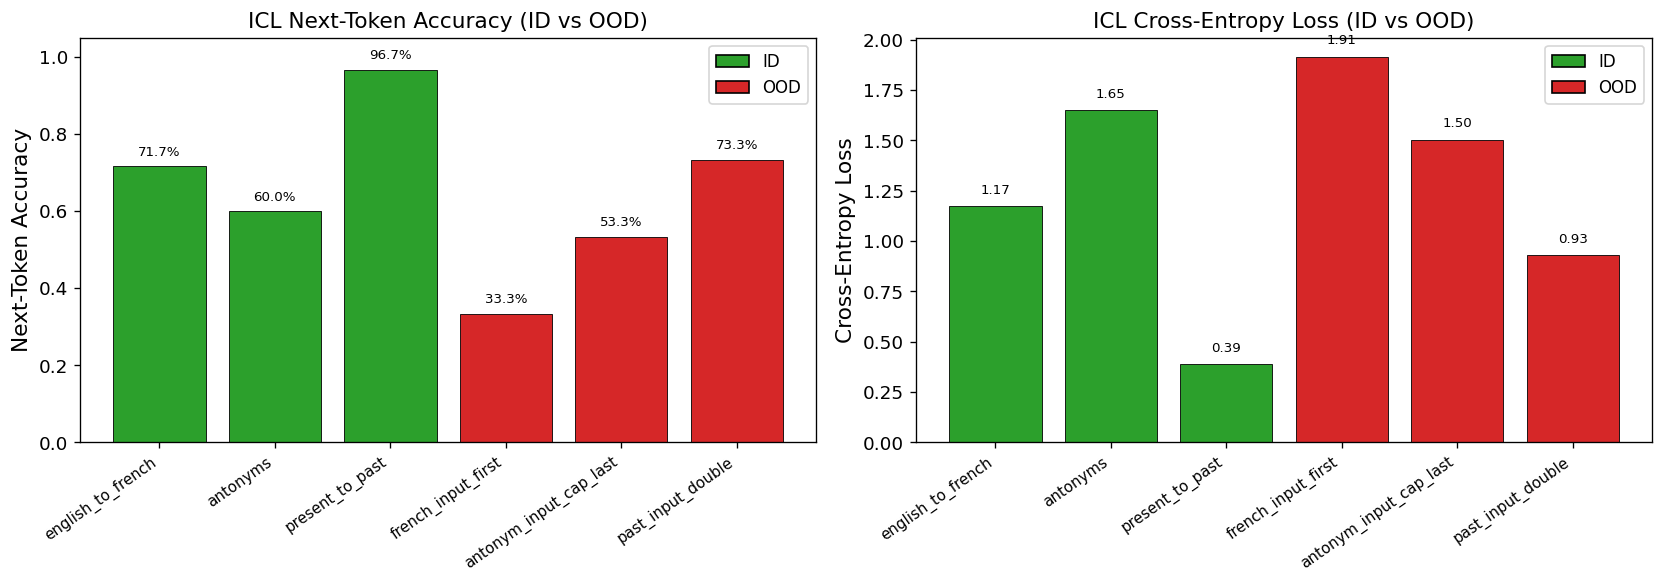

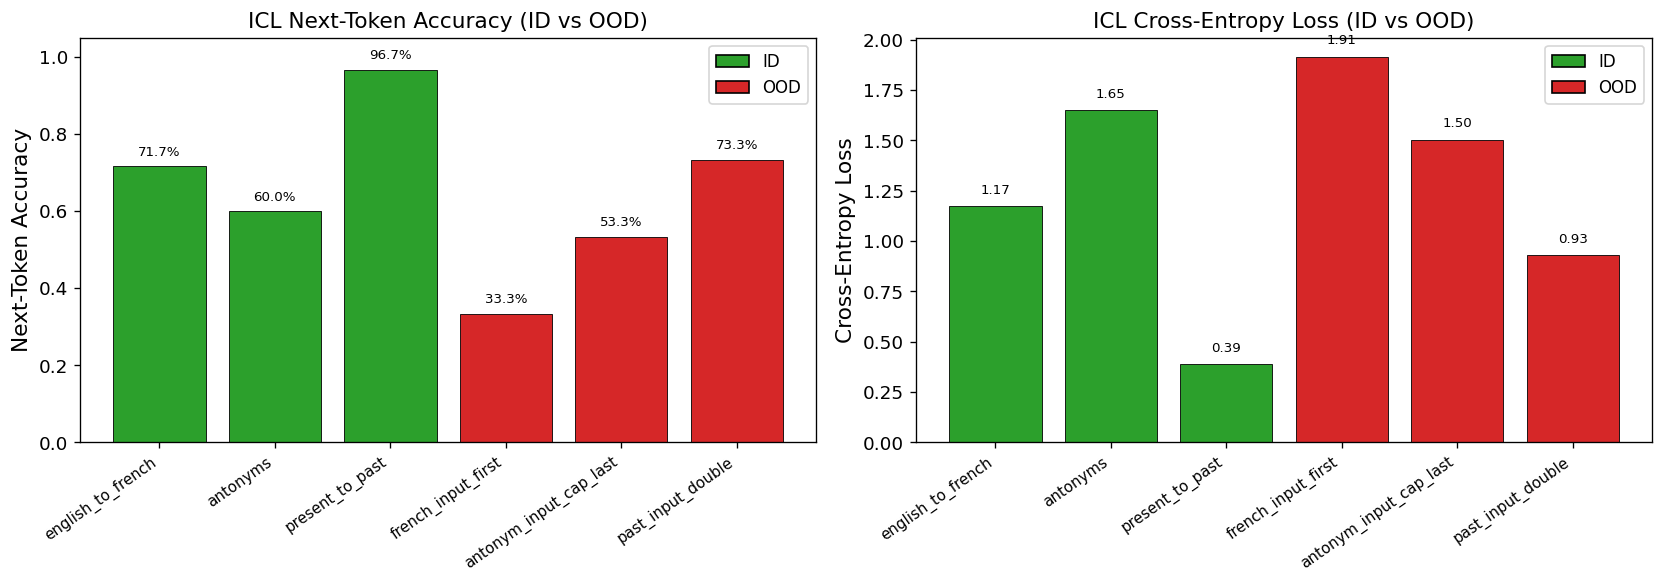

In [10]:
from icl.real_llm.plots import plot_performance_bars

plot_performance_bars(id_perf, ood_perf)

## 4. Extract Support Hidden States → Task Vectors

In [11]:
print('Extracting support hidden states (used to estimate task vectors)...')
support_hiddens = {}   # {task_name: (L, N_support, D)}

for task_name in exp.task_names:
    print(f'  Task: {task_name}')
    h = collect_hiddens(
        model, tokenizer,
        prompts=exp.support_prompts[task_name],
        layers=LAYERS,
        module_getter=module_getter,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        show_progress=True,
    )
    support_hiddens[task_name] = h
    print(f'    shape: {h.shape}   (L={h.shape[0]}, N={h.shape[1]}, D={h.shape[2]})')

# Compute centred task vectors τ_k(l) for every layer l
task_vecs, grand_mean = compute_task_vectors(support_hiddens, LAYERS)
# task_vecs : (L, K, D)   grand_mean : (L, D)
print(f'\nTask vectors shape: {task_vecs.shape}')

Extracting support hidden states (used to estimate task vectors)...
  Task: english_to_french
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])   (L=28, N=100, D=3584)
  Task: antonyms
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])   (L=28, N=100, D=3584)
  Task: present_to_past
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])   (L=28, N=100, D=3584)

Task vectors shape: torch.Size([28, 3, 3584])


In [12]:
# ── Extended task basis for λ-coefficient analysis ───────────────────────────
#
# The simplex trajectory plot uses only TASK_NAMES (K=3) because a 3-simplex
# is easy to visualise in 2D.  For the λ-trajectory analysis we can project
# onto a *wider* basis (more task vectors) to show that ID hidden states are
# selective even in a higher-dimensional space.
#
# Change the list below to include any extra tasks you want in the λ basis.
from icl.real_llm.task_data import build_experiment_prompts

LAMBDA_EXTRA_NAMES = ["singular_to_plural", "landmark_to_country", "english_to_spanish"]
LAMBDA_TASK_NAMES  = list(exp.task_names) + LAMBDA_EXTRA_NAMES

_extra_exp = build_experiment_prompts(
    n_support_prompts = N_SUPPORT_PROMPTS,
    n_eval_prompts    = N_EVAL_PROMPTS,
    n_shots           = N_SHOTS,
    n_support_pairs   = N_SUPPORT_PAIRS,
    seed              = SEED,
    task_names        = LAMBDA_EXTRA_NAMES,
)

# Collect support hidden states for the extra tasks
print('Extracting support hidden states for extra λ-basis tasks...')
lambda_support_hiddens = dict(support_hiddens)   # copy — keep original 3 intact
for task_name in LAMBDA_EXTRA_NAMES:
    print(f'  Task: {task_name}')
    h = collect_hiddens(
        model, tokenizer,
        prompts       = _extra_exp.support_prompts[task_name],
        layers        = LAYERS,
        module_getter = module_getter,
        batch_size    = BATCH_SIZE,
        device        = DEVICE,
        show_progress = True,
    )
    lambda_support_hiddens[task_name] = h
    print(f'    shape: {h.shape}')

# Recompute task vectors over all K_lambda tasks together
# (grand mean shifts when the set of tasks changes, so we recompute from scratch)
lambda_task_vecs, lambda_grand_mean = compute_task_vectors(lambda_support_hiddens, LAYERS)
K_lambda = len(LAMBDA_TASK_NAMES)
print(f'\nExtended task vectors shape: {lambda_task_vecs.shape}  (K={K_lambda})')
print(f'λ-basis tasks: {LAMBDA_TASK_NAMES}')

Extracting support hidden states for extra λ-basis tasks...
  Task: singular_to_plural
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])
  Task: landmark_to_country
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])
  Task: english_to_spanish
  Done (100 prompts, 28 layers)
    shape: torch.Size([28, 100, 3584])

Extended task vectors shape: torch.Size([28, 6, 3584])  (K=6)
λ-basis tasks: ['english_to_french', 'antonyms', 'present_to_past', 'singular_to_plural', 'landmark_to_country', 'english_to_spanish']


## 5. Extract ID Eval Hidden States

In [13]:
print('Extracting ID eval hidden states...')
id_eval_hiddens = {}   # {task_name: (L, N_eval, D)}

for task_name in exp.task_names:
    print(f'  Task: {task_name}')
    h = collect_hiddens(
        model, tokenizer,
        prompts=exp.id_eval_prompts[task_name],
        layers=LAYERS,
        module_getter=module_getter,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        show_progress=True,
    )
    id_eval_hiddens[task_name] = h

Extracting ID eval hidden states...
  Task: english_to_french
  Done (60 prompts, 28 layers)
  Task: antonyms
  Done (60 prompts, 28 layers)
  Task: present_to_past
  Done (60 prompts, 28 layers)


## 6. Extract OOD Eval Hidden States

In [14]:
print('Extracting OOD eval hidden states...')
ood_eval_hiddens = {}   # {ood_task_name: (L, N_eval, D)}

for ood_name in exp.ood_task_names:
    print(f'  OOD task: {ood_name}')
    h = collect_hiddens(
        model, tokenizer,
        prompts=exp.ood_eval_prompts[ood_name],
        layers=LAYERS,
        module_getter=module_getter,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        show_progress=True,
    )
    ood_eval_hiddens[ood_name] = h

Extracting OOD eval hidden states...
  OOD task: french_input_first
  Done (60 prompts, 28 layers)
  OOD task: antonym_input_cap_last
  Done (60 prompts, 28 layers)
  OOD task: past_input_double
  Done (60 prompts, 28 layers)


## 7. Analysis — Task-Subspace R² vs Layer

At each layer $l$, we measure what fraction of the eval hidden-state variance
is explained by simplex-projection onto $\mathrm{span}(\tau_1(l), \tau_2(l), \tau_3(l))$.

**Expected**: ID R² grows with depth; OOD R² stays lower (orthogonal component dominates).

In [15]:
from icl.real_llm.analysis import compute_r2_per_layer

# L is inferred from task_vecs shape (LAYERS=None → all layers extracted).
L = task_vecs.shape[0]
layers_range = list(range(L))
K = len(exp.task_names)

id_r2  = compute_r2_per_layer(id_eval_hiddens,  task_vecs, grand_mean)
ood_r2 = compute_r2_per_layer(ood_eval_hiddens, task_vecs, grand_mean)

print('Mean R² at last layer:')
for name, r2 in id_r2.items():
    print(f'  ID  {name}: {r2[-1]:.3f}')
for name, r2 in ood_r2.items():
    print(f'  OOD {name}: {r2[-1]:.3f}')

Mean R² at last layer:
  ID  english_to_french: 0.386
  ID  antonyms: 0.387
  ID  present_to_past: 0.430
  OOD french_input_first: 0.077
  OOD antonym_input_cap_last: 0.034
  OOD past_input_double: 0.083


In [16]:
# ── Full R² table: one row per layer, one column per group ───────────────────
import pandas as pd

id_names  = list(id_r2.keys())
ood_names = list(ood_r2.keys())

# Build DataFrame with clean column names
id_cols  = {n.replace('_', ' '): id_r2[n]  for n in id_names}
ood_cols = {n.replace('_', ' '): ood_r2[n] for n in ood_names}

df_id  = pd.DataFrame(id_cols,  index=range(L))
df_ood = pd.DataFrame(ood_cols, index=range(L))

# Multi-level columns: (Group, Task)
df_id.columns  = pd.MultiIndex.from_tuples([('ID  ✓', c) for c in df_id.columns])
df_ood.columns = pd.MultiIndex.from_tuples([('OOD ✗', c) for c in df_ood.columns])
df = pd.concat([df_id, df_ood], axis=1)
df.index = [f'{l}' for l in range(L)]
df.index.name = 'Layer'

# ── Per-column background gradient (independent scale per column) ─────────────
# ID cols: white→green  (high R² = good alignment)
# OOD cols: white→red   (high R² = bad, OOD should be orthogonal)
def _bg(s):
    col_name = s.name   # (group, task) tuple
    group    = col_name[0]
    lo, hi   = s.min(), s.max()
    rng      = max(hi - lo, 1e-6)
    styles   = []
    for v in s:
        t = (v - lo) / rng          # 0..1 normalised within this column
        if group.startswith('ID'):
            # white → forest green  (high R² = good → dark)
            r = int(255 - t * (255 - 34))
            g = int(255 - t * (255 - 139))
            b = int(255 - t * (255 - 34))
        else:
            # white → crimson, but INVERTED: low R² = dark (orthogonality is good)
            t_inv = 1.0 - t
            r = int(255 - t_inv * (255 - 180))
            g = int(255 - t_inv * (255 - 30))
            b = int(255 - t_inv * (255 - 45))
        styles.append(f'background-color: rgb({r},{g},{b}); color: #111')
    return styles

# Bold the "best" value in each column:
#   ID  → max R² (strongest alignment)
#   OOD → min R² (strongest orthogonality)
def _bold_best(s):
    group   = s.name[0]
    target  = s.min() if group.startswith('OOD') else s.max()
    return ['font-weight: bold; text-decoration: underline'
            if v == target else '' for v in s]

model_short = MODEL_NAME.split('/')[-1]
styled = (
    df.style
    .format('{:.3f}')
    .apply(_bg,       axis=0)
    .apply(_bold_best, axis=0)
    .set_caption(
        f'Task-subspace R²  per layer  ·  {model_short}  '
        f'·  ID: high = ✓  ·  OOD: low = ✓'
    )
    .set_table_styles([
        # caption
        {'selector': 'caption',
         'props': 'font-size:13px; font-weight:bold; padding:6px 0 10px 0; text-align:left;'},
        # index column
        {'selector': 'th.row_heading',
         'props': 'font-family:monospace; font-size:11px; text-align:right; padding:1px 6px;'},
        # all header cells
        {'selector': 'th',
         'props': 'font-size:11px; text-align:center; padding:3px 8px; white-space:nowrap;'},
        # data cells
        {'selector': 'td',
         'props': 'font-size:11px; text-align:right; padding:1px 8px; font-family:monospace;'},
        # group-level header (ID / OOD)
        {'selector': 'th.col_heading.level0',
         'props': 'font-size:12px; font-weight:bold; border-bottom:2px solid #555;'},
        # alternating row shading (subtle)
        {'selector': 'tr:nth-child(even)',
         'props': 'filter: brightness(0.97);'},
    ])
)
display(styled)

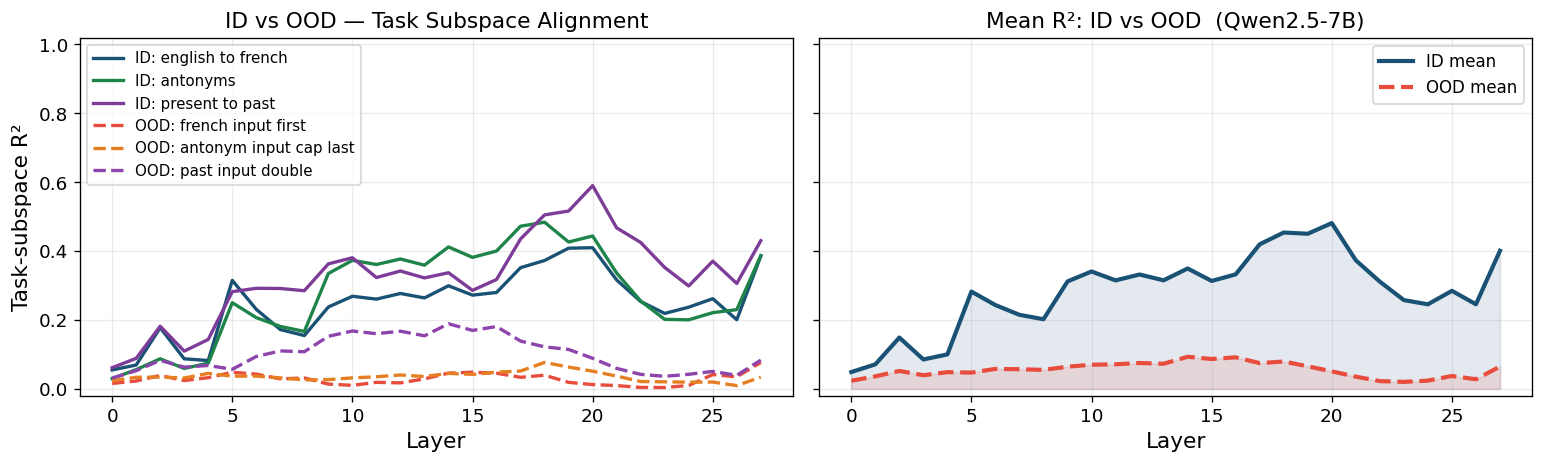

In [17]:
import os
from icl.real_llm.plots import plot_r2_vs_layer

os.makedirs('../paper_figs', exist_ok=True)
results = plot_r2_vs_layer(id_r2, ood_r2, layers_range,
                           model_name=MODEL_NAME,
                           save_path='../paper_figs/real_llm_r2_vs_layer.png')

## 8b. Analysis — Per-Layer Positional Trajectory Plots

For each selected layer, one combined figure shows **how hidden states evolve across in-context shot positions** (style of `traj_posterior_projection_plot` from Latent.ipynb):

- **Task vectors**: estimated from the support set at the **last token of each prompt** (query position), separately per layer.
- **Projection plane**: defined by *that layer's* task vectors. All tasks (ID + OOD) are projected onto the same 2D plane.
- **Trajectory "time" axis = shot index** (1 … N_shots): for each eval prompt, we extract the hidden state at the last token of each in-context example, forming a trajectory of length N_shots.
- **Stars ★** at the three ID task-vector positions; **dashed triangle** connecting them (reference frame).
- **Unconstrained affine OLS** coefficients λ (Σλ = 1, no λ ≥ 0 constraint) — OOD samples can and do fall outside the simplex.

Computing shot positions for eval prompts...
  T = 21 positions per prompt  (shots 1..20 + query).  Done.
Extracting ID trajectory hidden states...
  Task: english_to_french
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: antonyms
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: present_to_past
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
Extracting OOD trajectory hidden states...
  Task: french_input_first
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: antonym_input_cap_last
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: past_input_double
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
Plotting trajectories for layers: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


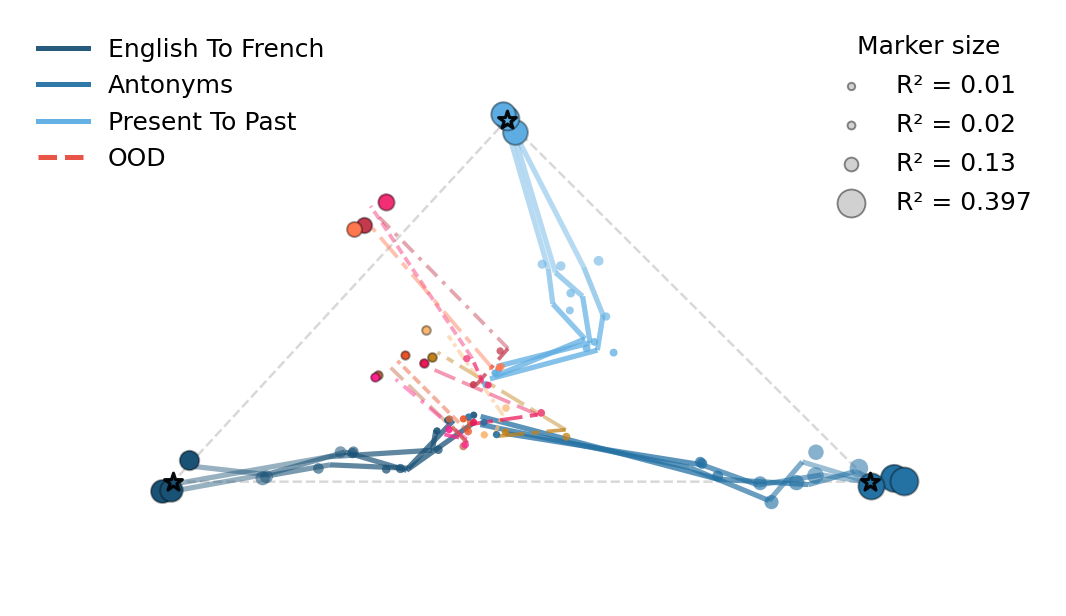

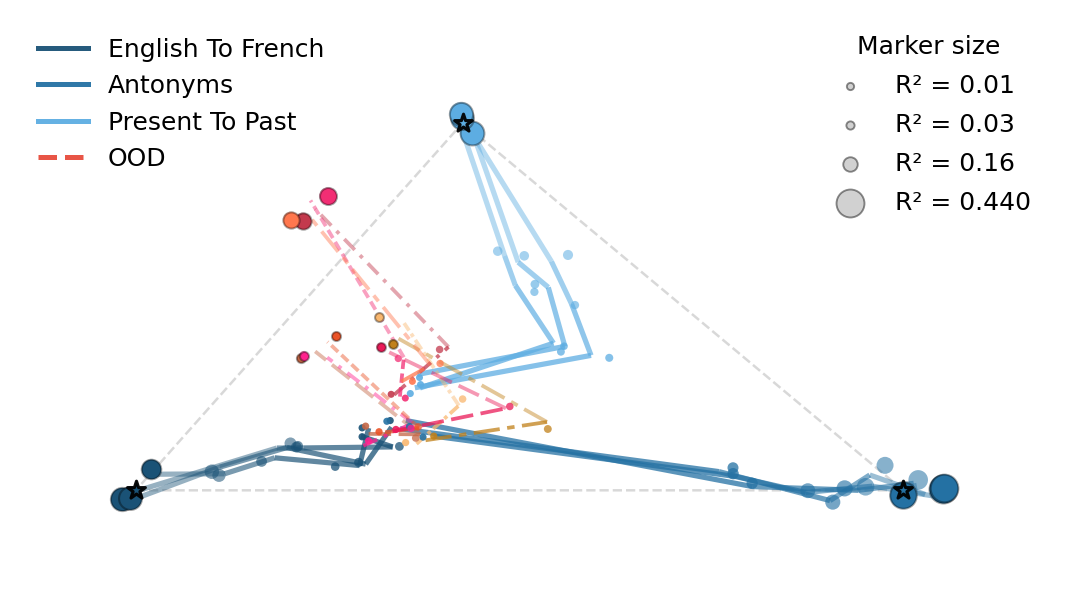

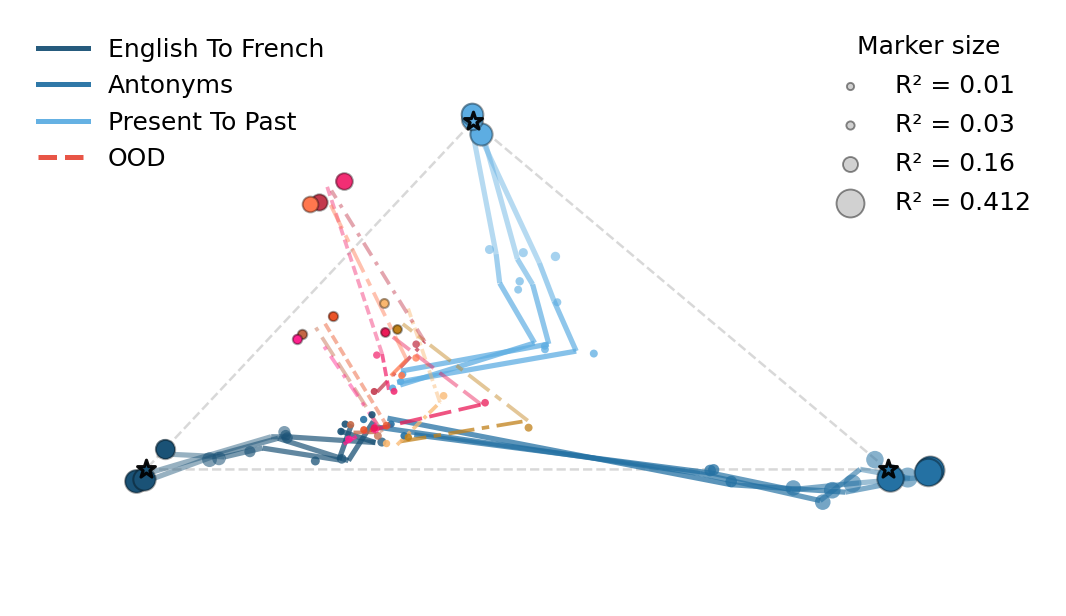

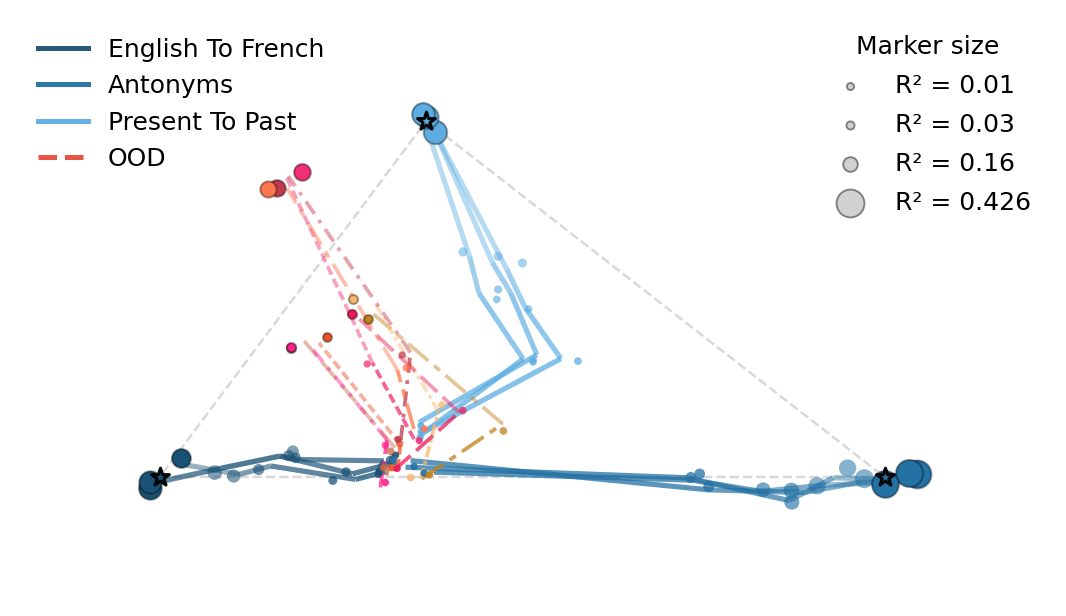

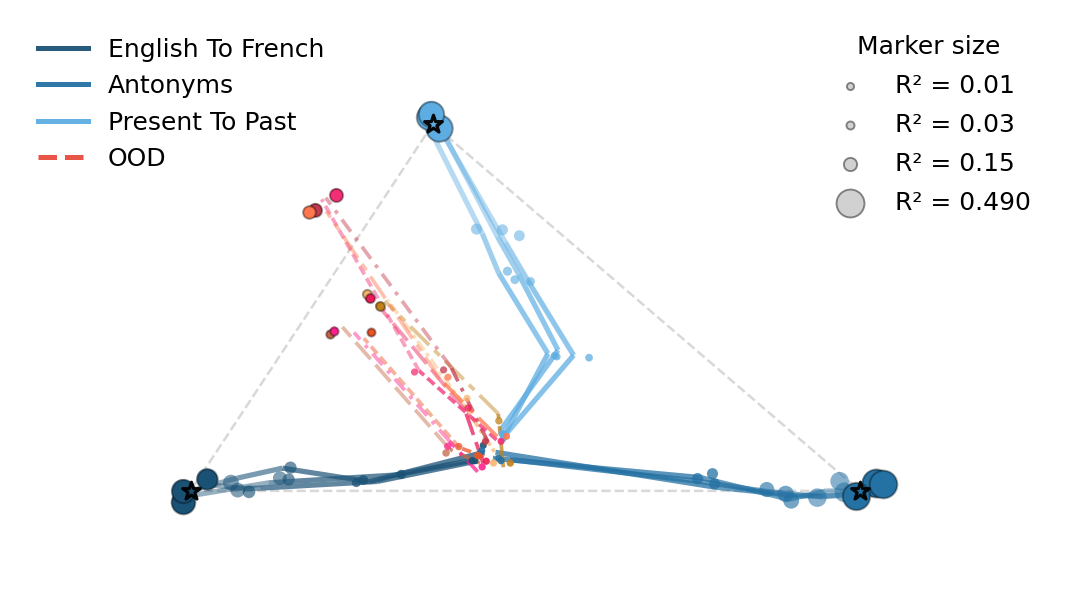

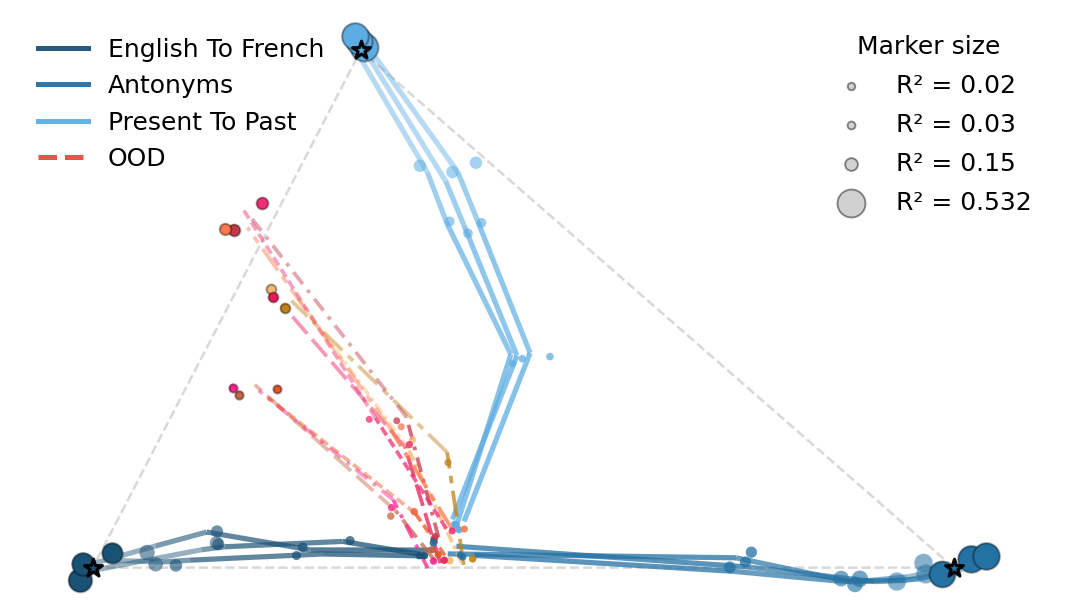

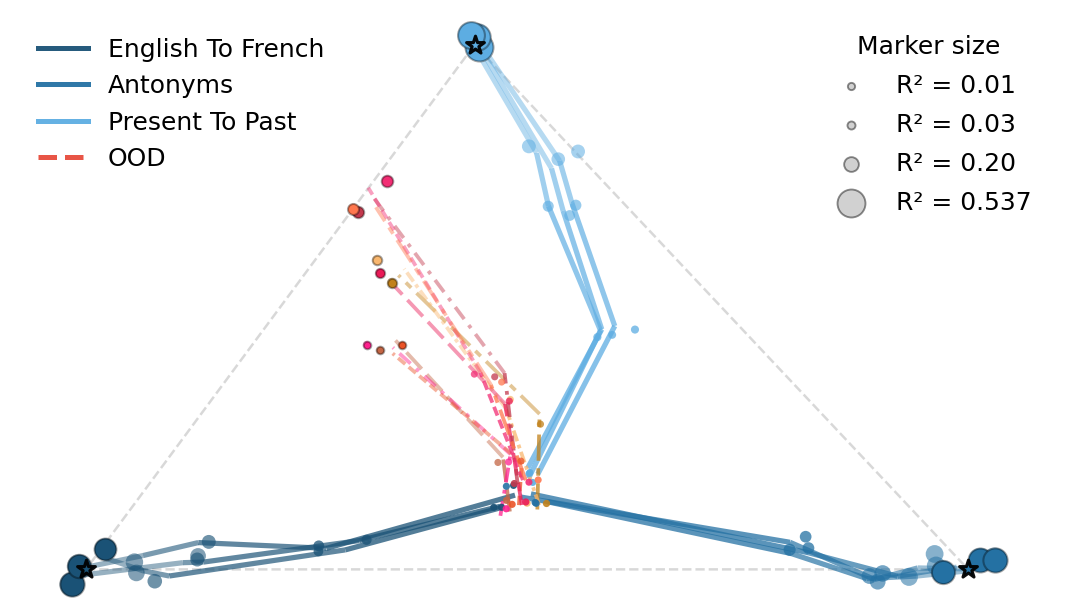

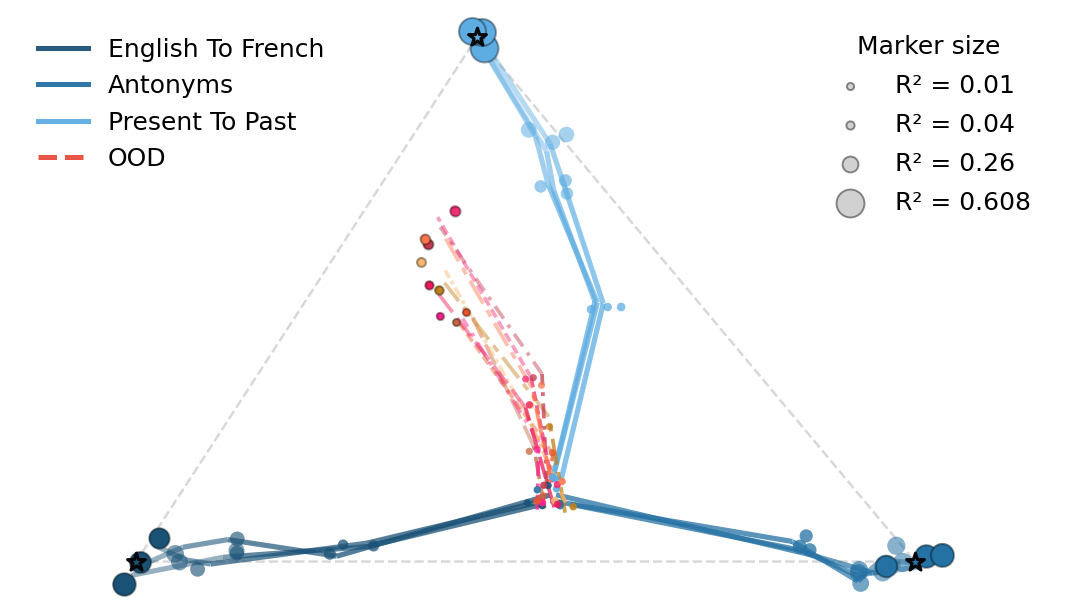

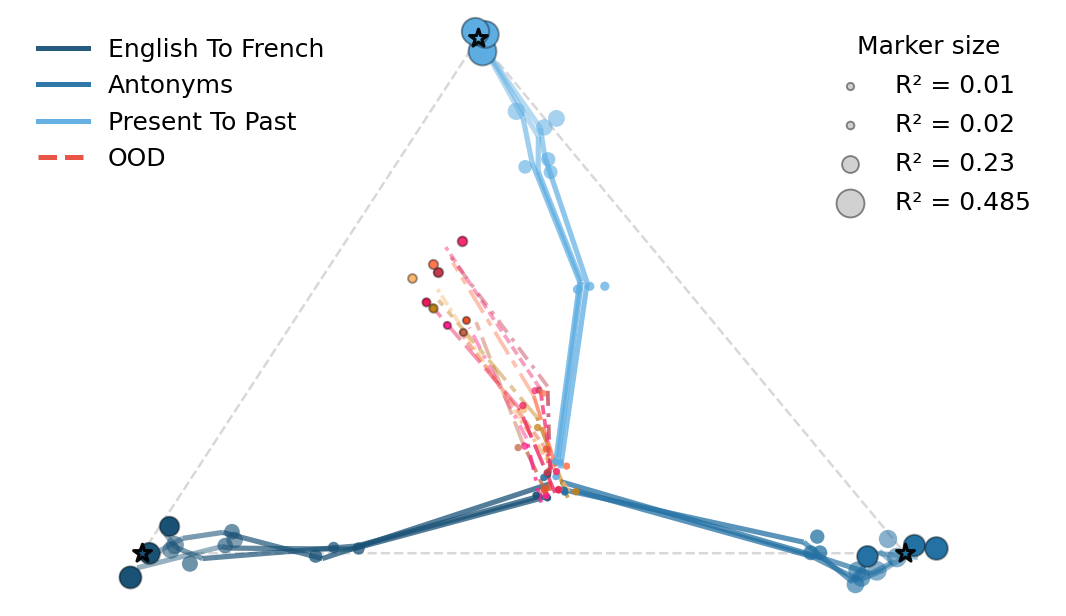

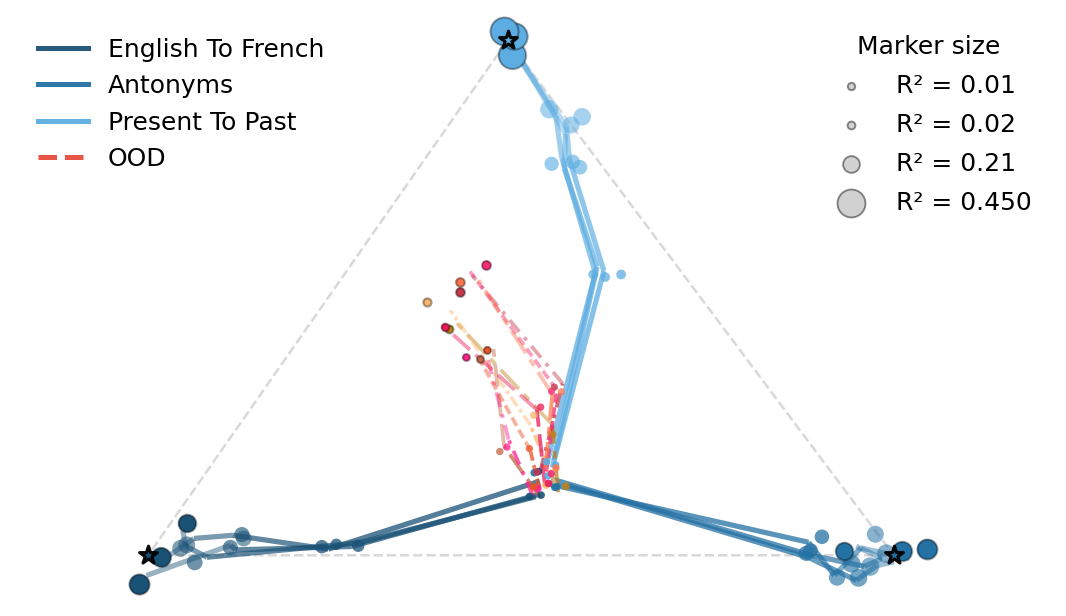

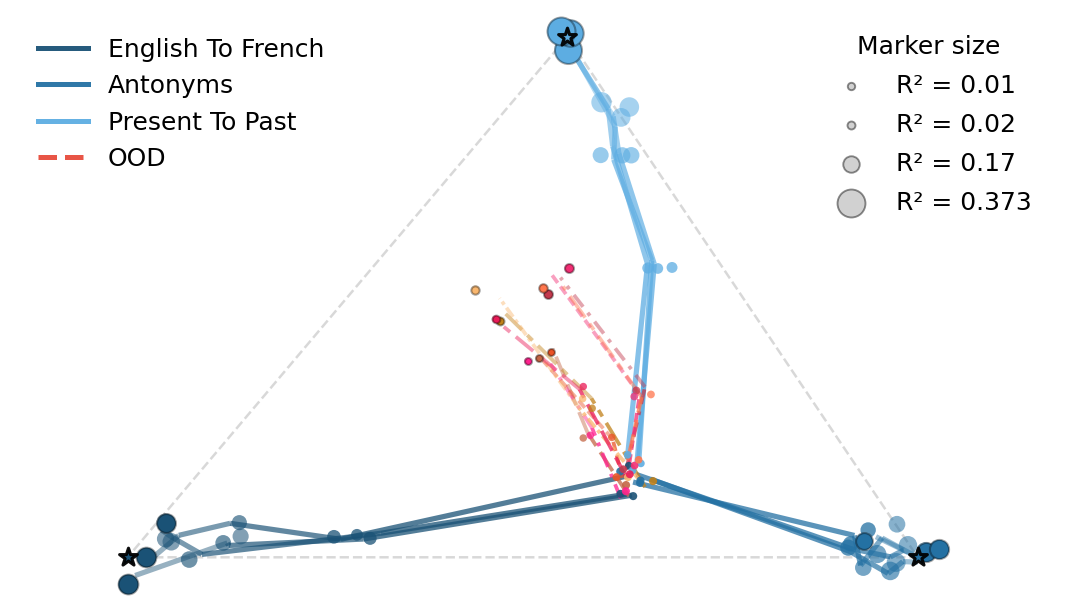

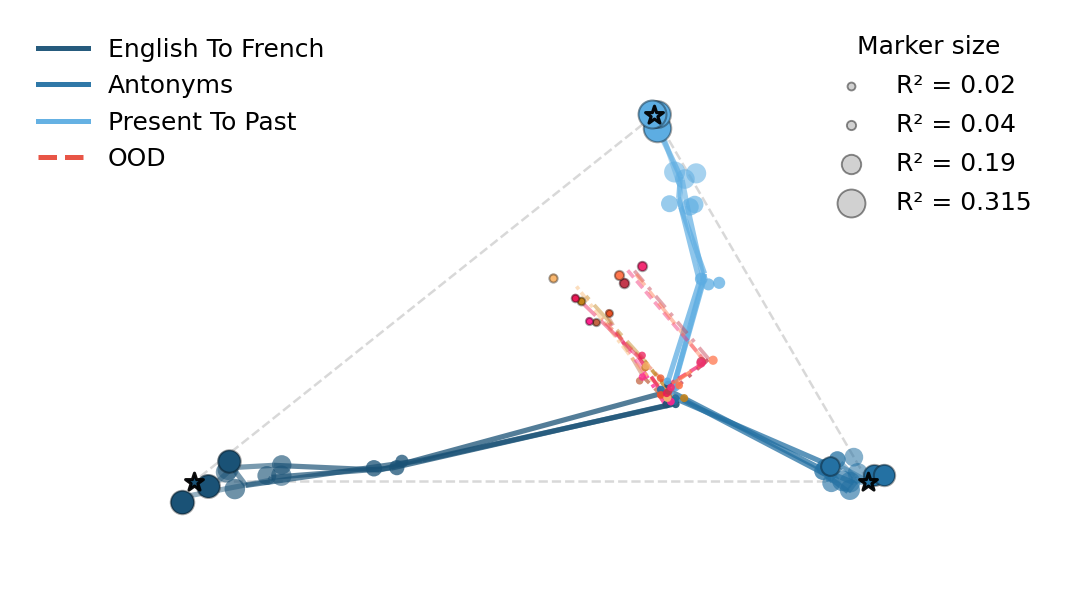

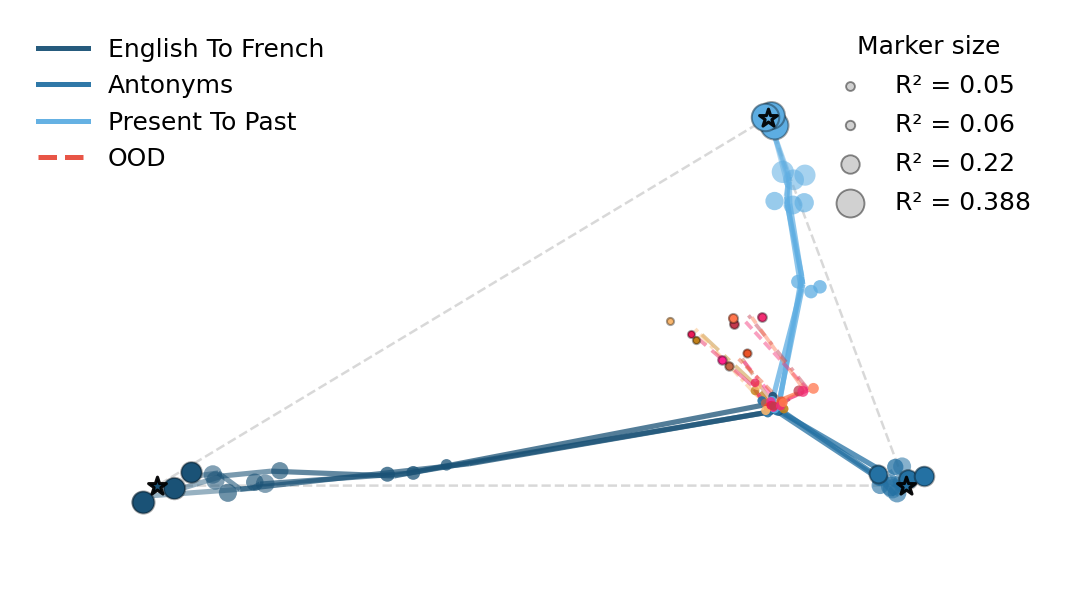

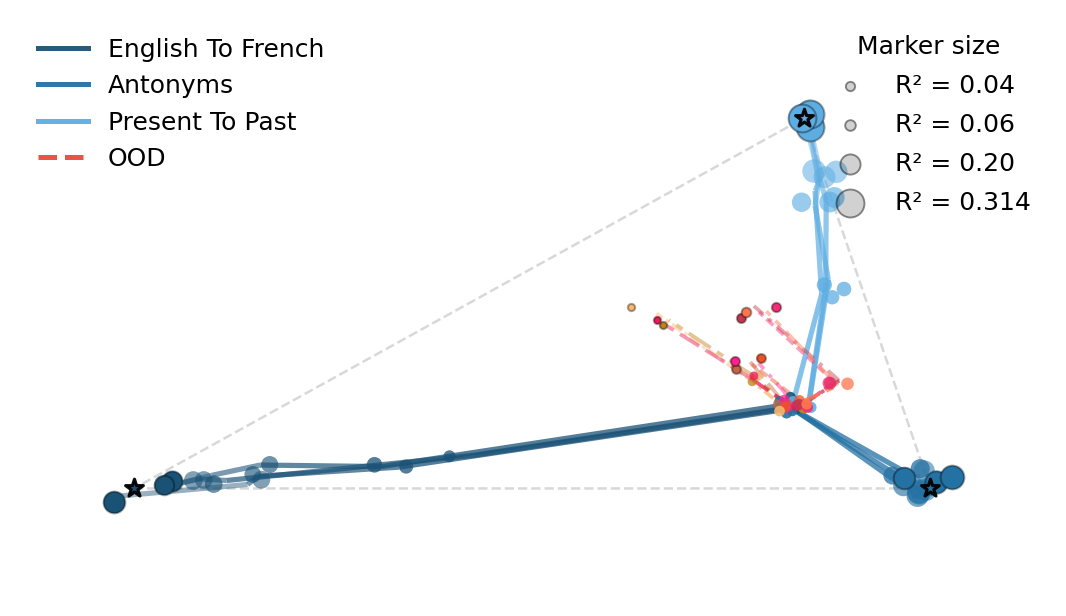

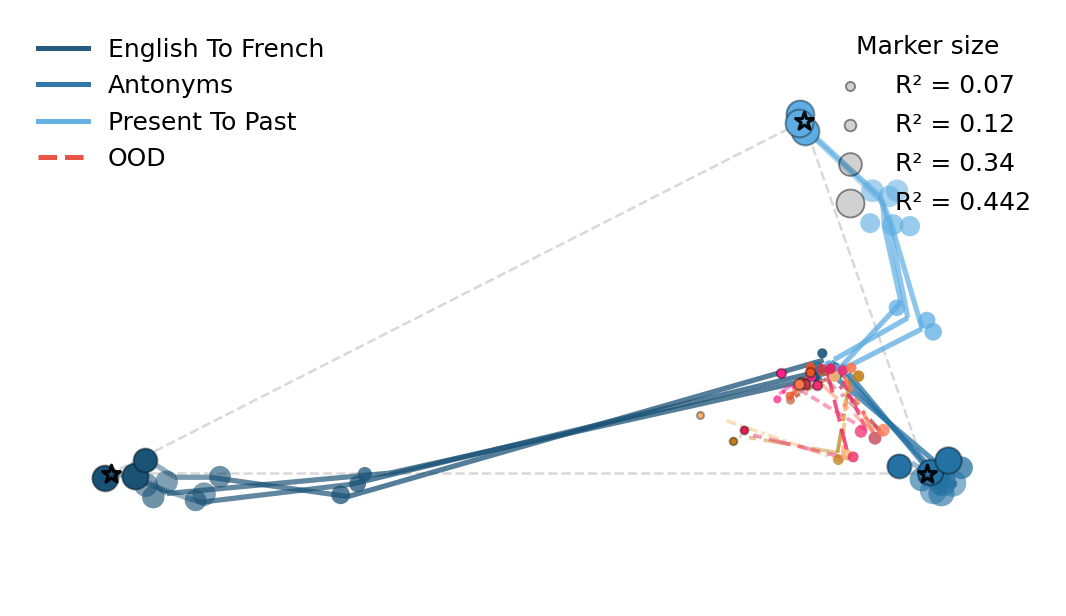

In [20]:
# ── Per-layer positional trajectory plot (style of Latent.ipynb) ─────────────
#
# Trajectory "time" axis = position index within the N-shot prompt:
#   t=0  → hidden state at last token of in-context example 1
#   t=1  → hidden state at last token of in-context example 2
#   ...
#   t=N_SHOTS-1  → hidden state at last token of in-context example N_SHOTS
#   t=N_SHOTS    → hidden state at the QUERY token (= where task vectors are
#                  estimated via collect_hiddens).  This is the endpoint.
#
# Because the endpoint (t=N_SHOTS) and the task-vector stars (★) both come
# from the query position, ID trajectories should converge to the correct
# simplex corner by the end.
#
# Non-overlap guarantee:
#   Stars  ← support pool  (50 distinct prompts per task, disjoint from eval)
#   Trajectories ← eval pool (60 distinct prompts per task, disjoint from support)
#
# Displayed positions per trajectory:
#   ID:  shots 1, 2, 3, 4  and the query position  → t_show = [0, 1, 2, 3, -1]
#   OOD: shots 1, 2  and  query position            → ood_t_show = [0, 1, -1]

import importlib

# Reload hf_extractor
import icl.real_llm.hf_extractor as _hfe
importlib.reload(_hfe)
from icl.real_llm.hf_extractor import get_shot_positions, collect_hiddens_trajectory

# Reload traj_plot submodules so edits to _draw.py / _main.py are picked up
import icl.utils.traj_plot._helpers as _tph
import icl.utils.traj_plot._prepare as _tpp
import icl.utils.traj_plot._time_indices as _tpti
import icl.utils.traj_plot._styles as _tps
import icl.utils.traj_plot._draw as _tpd
import icl.utils.traj_plot._annotate as _tpa
import icl.utils.traj_plot._main as _tpm
import icl.utils.traj_plot as _tp
for _mod in [_tph, _tpp, _tpti, _tps, _tpd, _tpa, _tpm, _tp]:
    importlib.reload(_mod)
from icl.utils.traj_plot import project_with_r2_trajectories_group_colors_mpl

# Marker-size legend (default in traj_plot._draw): R² ticks at quantiles 0.2 / 0.5 / 0.8
# (rounded); the largest legend marker uses global max(R²), not the 95th percentile.
# Omit legend_r2_values below to use this rule. Reload _tpd if you edit _draw.py.

task_names_list = list(exp.task_names)
ood_names_list  = list(exp.ood_task_names)
K_id    = len(task_names_list)
K_ood   = len(ood_names_list)
K_total = K_id + K_ood

task_labels_traj = (
    [n.replace('_', ' ') for n in task_names_list]
    + [n.replace('_', ' ') for n in ood_names_list]
)

# ── Step 1: compute shot boundary positions (CPU-only, fast) ─────────────────
# include_query=True → T = N_SHOTS + 1; last position = query token (same as
# where task vectors are extracted by collect_hiddens).
print('Computing shot positions for eval prompts...')
shot_positions_id = {
    name: [get_shot_positions(p, tokenizer, N_SHOTS, include_query=True)
           for p in exp.id_eval_prompts[name]]
    for name in task_names_list
}
shot_positions_ood = {
    name: [get_shot_positions(p, tokenizer, N_SHOTS, include_query=True)
           for p in exp.ood_eval_prompts[name]]
    for name in ood_names_list
}
T_traj = N_SHOTS + 1   # N_SHOTS shot positions + query position
print(f'  T = {T_traj} positions per prompt  (shots 1..{N_SHOTS} + query).  Done.')

# ── Step 2: extract trajectory hidden states — (L, T, N_eval, D) ─────────────
print('Extracting ID trajectory hidden states...')
id_traj_hiddens = {}
for name in task_names_list:
    print(f'  Task: {name}')
    h = collect_hiddens_trajectory(
        model, tokenizer,
        prompts             = exp.id_eval_prompts[name],
        shot_positions_list = shot_positions_id[name],
        layers              = list(range(L)),
        module_getter       = module_getter,
        batch_size          = max(1, BATCH_SIZE // 2),
        device              = DEVICE,
        show_progress       = True,
    )
    id_traj_hiddens[name] = h   # (L, T, N_eval, D)
    print(f'    shape: {h.shape}')

print('Extracting OOD trajectory hidden states...')
ood_traj_hiddens = {}
for name in ood_names_list:
    print(f'  Task: {name}')
    h = collect_hiddens_trajectory(
        model, tokenizer,
        prompts             = exp.ood_eval_prompts[name],
        shot_positions_list = shot_positions_ood[name],
        layers              = list(range(L)),
        module_getter       = module_getter,
        batch_size          = max(1, BATCH_SIZE // 2),
        device              = DEVICE,
        show_progress       = True,
    )
    ood_traj_hiddens[name] = h   # (L, T, N_eval, D)
    print(f'    shape: {h.shape}')

# ── Step 3: choose which layers to display ───────────────────────────────────
n_show = min(8, L)
selected_layers = list(range(13,28))
print(f'Plotting trajectories for layers: {selected_layers}')

# ── Step 4 & 5: per-layer trajectory plots ───────────────────────────────────
for l_idx in selected_layers:
    tvecs_l = task_vecs[l_idx].float()   # (K_id, D) — centred task vectors at this layer
    mu_l    = grand_mean[l_idx].float()  # (D,)

    # Collect and centre: one (T, N_eval, D) per group
    all_h_list = []
    for name in task_names_list:
        h = id_traj_hiddens[name][l_idx].float()   # (T, N, D)
        all_h_list.append(h - mu_l.unsqueeze(0).unsqueeze(0))
    for name in ood_names_list:
        h = ood_traj_hiddens[name][l_idx].float()  # (T, N, D)
        all_h_list.append(h - mu_l.unsqueeze(0).unsqueeze(0))

    # (K_total, T, N_eval, D) — plotting function expects (K, T, B, D)
    all_h_4d = torch.stack(all_h_list, dim=0)
    K_t, T, N_eval, D_h = all_h_4d.shape

    # ── Filter to display positions: shots 1–4 + query ─────────────────────
    # By keeping only these time indices, lines connect them directly
    # (no invisible intermediate positions causing the path to meander).
    display_t = [0, 1, 2, 3, T - 1]   # shots 1,2,3,4 + query
    T_disp    = len(display_t)

    h_disp = all_h_4d[:, display_t, :, :]   # (K_total, T_disp, N_eval, D)

    # ── Per-sample per-position R² on display positions ──────────────────────
    r2_list = []
    for t_idx in display_t:
        h_t = all_h_4d[:, t_idx, :, :]
        _, r2_t, _, _ = estimate_lambda_with_r2(
            tvecs_l, h_t, is_zero_mean=True,
        )
        r2_list.append(r2_t)
    r2_disp = np.stack(r2_list, axis=-1)   # (K_total, N_eval, T_disp)

    # ── Pre-average in groups of N_GROUP for smoother trajectories ───────────
    N_GROUP  = 20
    n_groups = N_eval // N_GROUP           # e.g. 60 // 10 = 6 averaged trajectories
    n_used   = n_groups * N_GROUP

    h_np = h_disp.numpy()[:, :, :n_used, :]                        # (K, T_disp, n_used, D)
    h_np = h_np.reshape(K_t, T_disp, n_groups, N_GROUP, D_h)
    h_np = h_np.mean(axis=3)                                        # (K, T_disp, n_groups, D)

    r2_grp = r2_disp[:, :n_used, :]                                 # (K, n_used, T_disp)
    r2_grp = r2_grp.reshape(K_t, n_groups, N_GROUP, T_disp)
    r2_grp = r2_grp.mean(axis=2)                                    # (K, n_groups, T_disp)

    # ── Plot ─────────────────────────────────────────────────────────────────────
    fig, ax = project_with_r2_trajectories_group_colors_mpl(
        task_vecs_over_all_time = h_np,               # (K_total, T_disp, n_groups, D)
        final_task_vecs         = tvecs_l.numpy(),    # (K_id, D) — this layer
        r2_scores               = r2_grp,             # (K_total, n_groups, T_disp)
        task_labels             = task_labels_traj,
        n_ood                   = K_ood,
        n_minor                 = 0,
        use_mean                = False,
        b_major                 = n_groups,
        b_ood                   = n_groups,
        ood_t_show_override     = [0, 1, -1],         # OOD: shots 1, 2 + query
        annotate                = False,
        show_pow2_anchors       = False,
        figsize                 = (7, 3.0),
        title                   = '',
        ood_legend_label        = 'OOD',
        major_colors            = ('#1a5276', '#2471a3', '#5dade2'),
        ood_base_color          = '#e74c3c',
        size_min                = 5,
        size_max                = 20,
        mid_size_factor         = 0.45,
        jitter_scale            = 0.013,
        line_alpha_end          = 0.75,
        point_alpha_start       = 0.90,
        point_alpha_end         = 0.50,
        major_line_width        = 2.5,
        line_width              = 1.8,
        end_marker_alpha        = 1.0,
        base_fontsize           = 13,
    )
    ax.set_aspect(0.85, adjustable='datalim')
    import os
    os.makedirs('../paper_figs', exist_ok=True)
    fname = f'../paper_figs/real_llm_traj_l{l_idx:02d}.png'
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [19]:
# ── Extract trajectory hidden states for extra λ-basis tasks ─────────────────
# id_traj_hiddens already contains the original TASK_NAMES.
# We build lambda_traj_hiddens by adding the extra tasks on top.

print('Computing shot positions for extra λ-basis tasks...')
_extra_shot_pos = {
    name: [
        get_shot_positions(p, tokenizer, N_SHOTS, include_query=True)
        for p in _extra_exp.id_eval_prompts[name]
    ]
    for name in LAMBDA_EXTRA_NAMES
}

print('Extracting trajectory hidden states for extra λ-basis tasks...')
lambda_traj_hiddens = dict(id_traj_hiddens)   # start from existing 3 tasks
for name in LAMBDA_EXTRA_NAMES:
    print(f'  Task: {name}')
    h = collect_hiddens_trajectory(
        model, tokenizer,
        prompts             = _extra_exp.id_eval_prompts[name],
        shot_positions_list = _extra_shot_pos[name],
        layers              = list(range(L)),
        module_getter       = module_getter,
        batch_size          = max(1, BATCH_SIZE // 2),
        device              = DEVICE,
        show_progress       = True,
    )
    lambda_traj_hiddens[name] = h
    print(f'    shape: {h.shape}')

print(f'Done. λ-traj tasks ({len(lambda_traj_hiddens)}): {list(lambda_traj_hiddens.keys())}')

Computing shot positions for extra λ-basis tasks...
Extracting trajectory hidden states for extra λ-basis tasks...
  Task: singular_to_plural
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: landmark_to_country
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
  Task: english_to_spanish
  Done (60 prompts × 21 positions, 28 layers)
    shape: torch.Size([28, 21, 60, 3584])
Done. λ-traj tasks (6): ['english_to_french', 'antonyms', 'present_to_past', 'singular_to_plural', 'landmark_to_country', 'english_to_spanish']


## 9. Analysis — Affine Coefficient λ_k vs Layer

For each eval prompt, compute the **unconstrained affine OLS** decomposition:

$$h_l^{\text{centred}} \approx \sum_k \lambda_k \,\tau_k(l), \quad \sum_k \lambda_k = 1 \text{ (no } \lambda_k \ge 0 \text{ constraint)}$$

Coefficients are computed by `simplex_trajectory` (affine OLS, no non-negativity clipping).

**Expected**:
- For an ID prompt from task $k$: $\lambda_k$ should grow toward 1 as depth increases, with the other components near 0.
- For an OOD prompt: $\lambda_k$ stays diffuse / near $1/K$ (uniform), showing no clear task preference.

In [20]:
# Compute position-wise unconstrained affine coefficients λ_k at selected layers.
# Uses the extended λ-basis (LAMBDA_TASK_NAMES, K_lambda tasks) and
# lambda_traj_hiddens / ood_traj_hiddens.
# For each layer l and position t:  h_{l,t} - μ_l ≈ Σ_k λ_k τ_k(l),  Σ λ_k = 1

from icl.real_llm.analysis import compute_lambda_trajectories

LAMBDA_LAYERS = list(range(16, 23))

beta_pos_id, beta_pos_ood = compute_lambda_trajectories(
    task_names       = LAMBDA_TASK_NAMES,
    ood_task_names   = list(exp.ood_task_names),
    id_traj_hiddens  = lambda_traj_hiddens,
    ood_traj_hiddens = ood_traj_hiddens,
    task_vecs        = lambda_task_vecs,
    grand_mean       = lambda_grand_mean,
    layers           = LAMBDA_LAYERS,
    T_traj           = T_traj,
)
print(f'Computed λ at layers {LAMBDA_LAYERS}')
print(f'  Shape per group: (T={T_traj}, N_eval, K={K_lambda})')

Computed λ at layers [16, 17, 18, 19, 20, 21, 22]
  Shape per group: (T=21, N_eval, K=6)


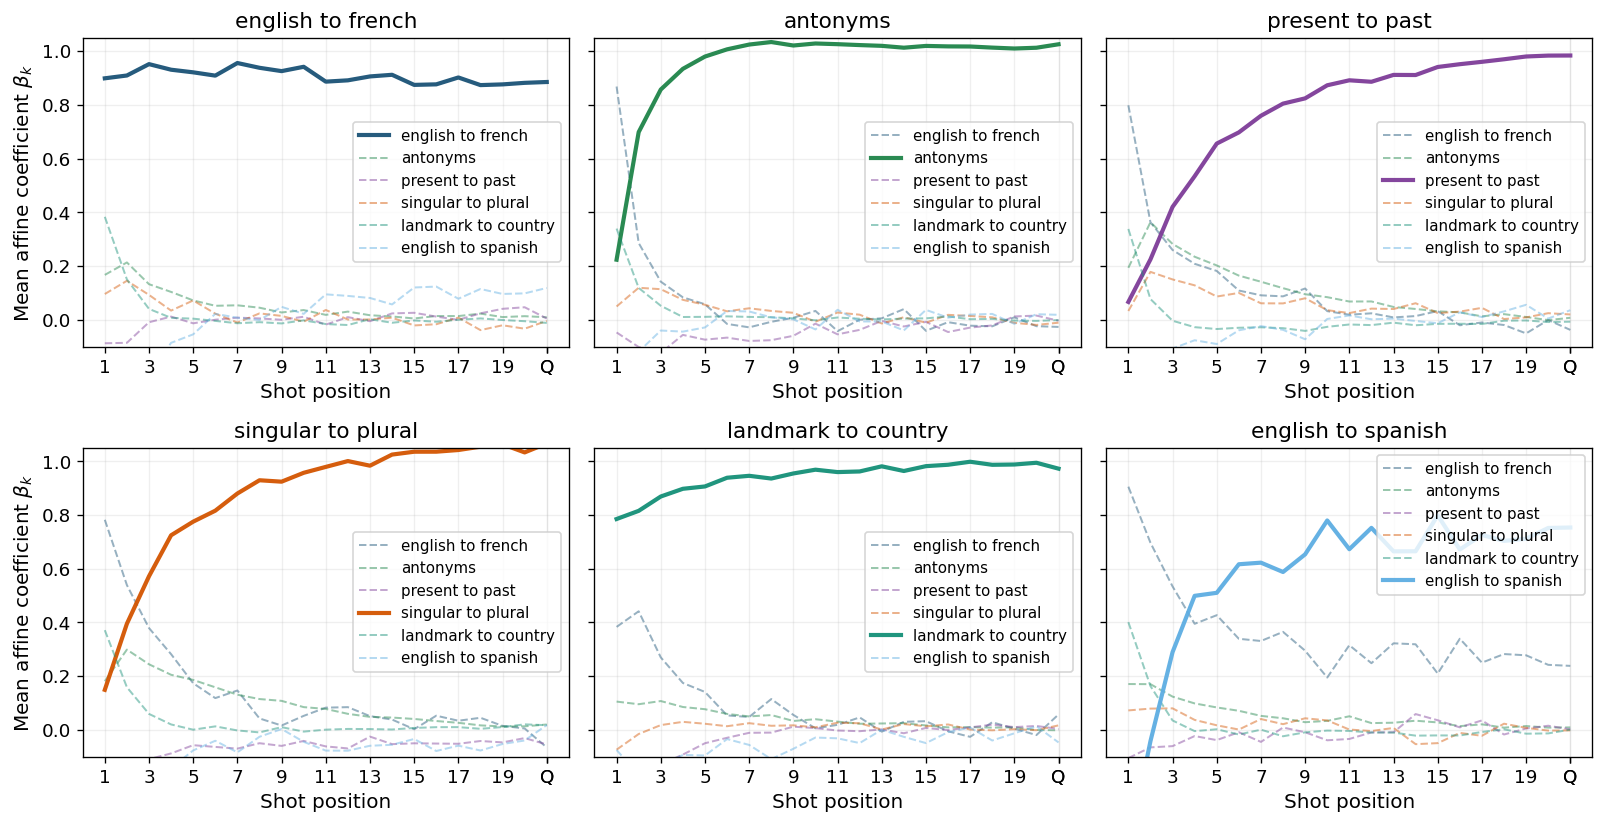

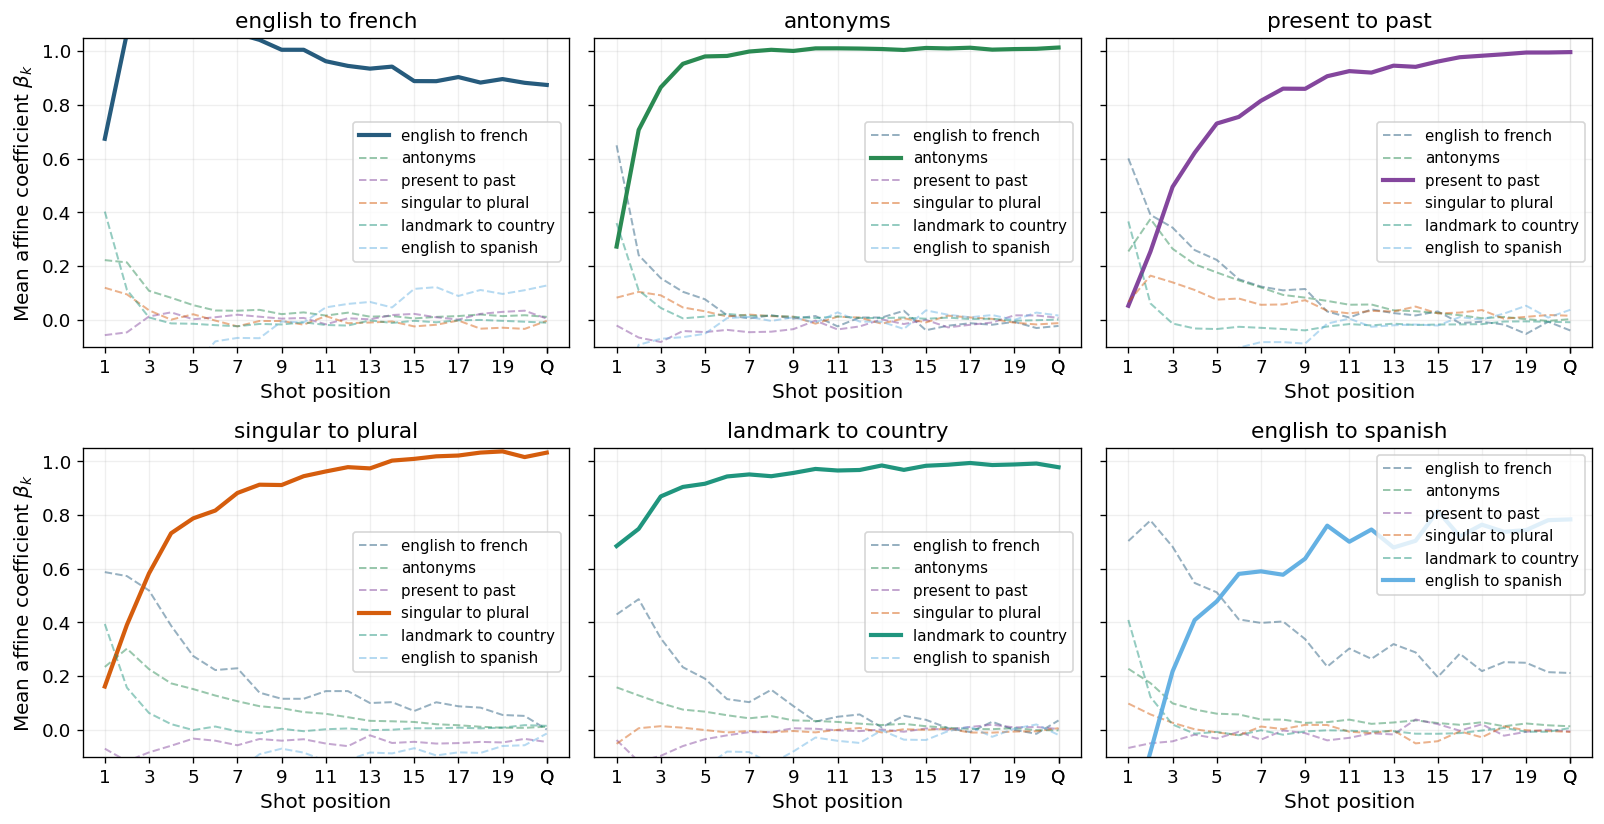

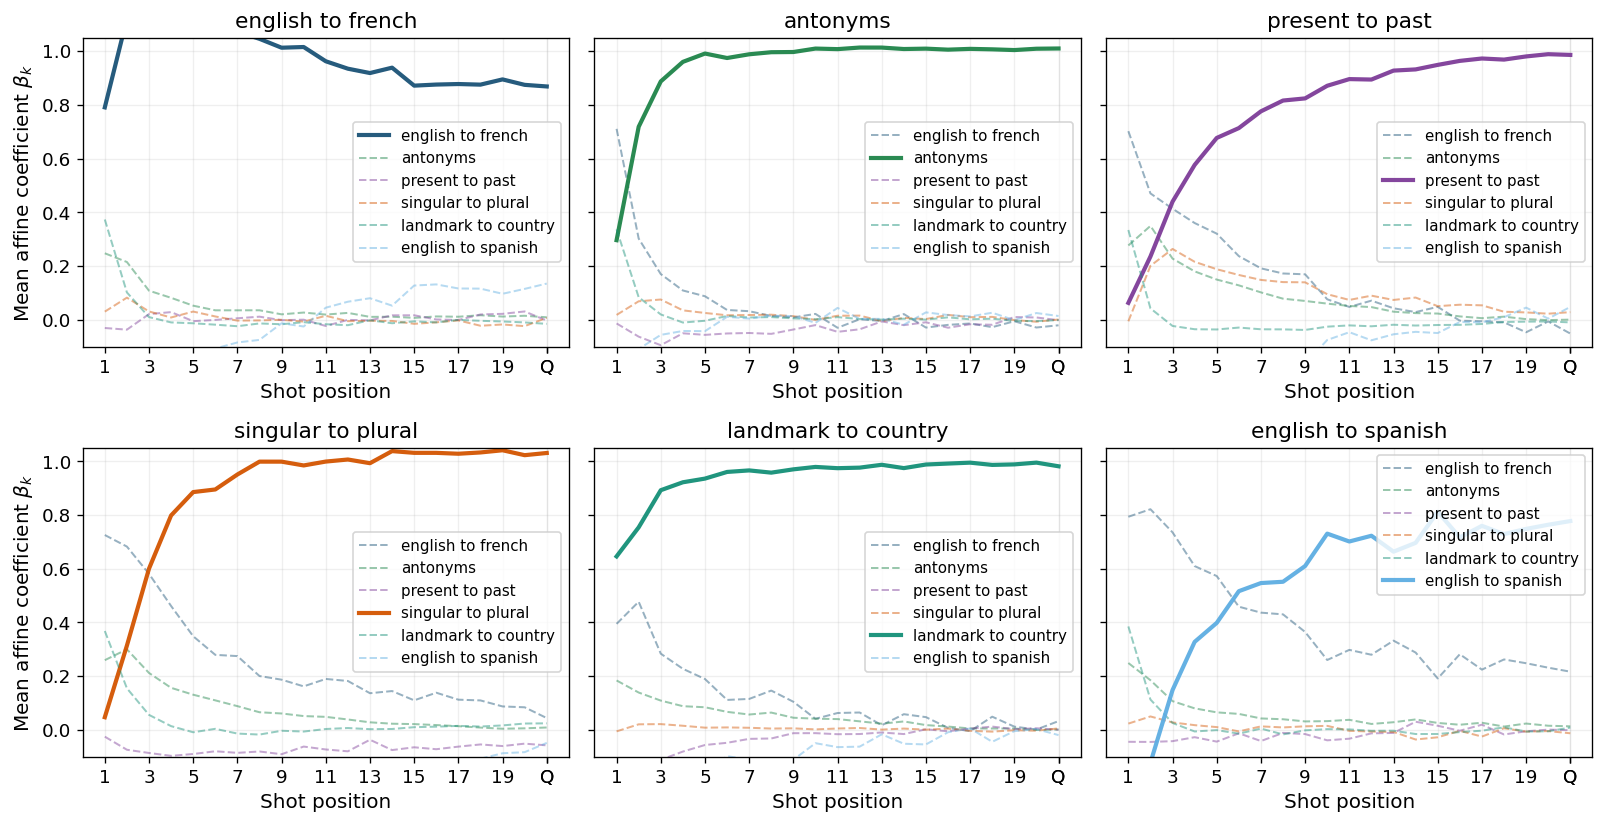

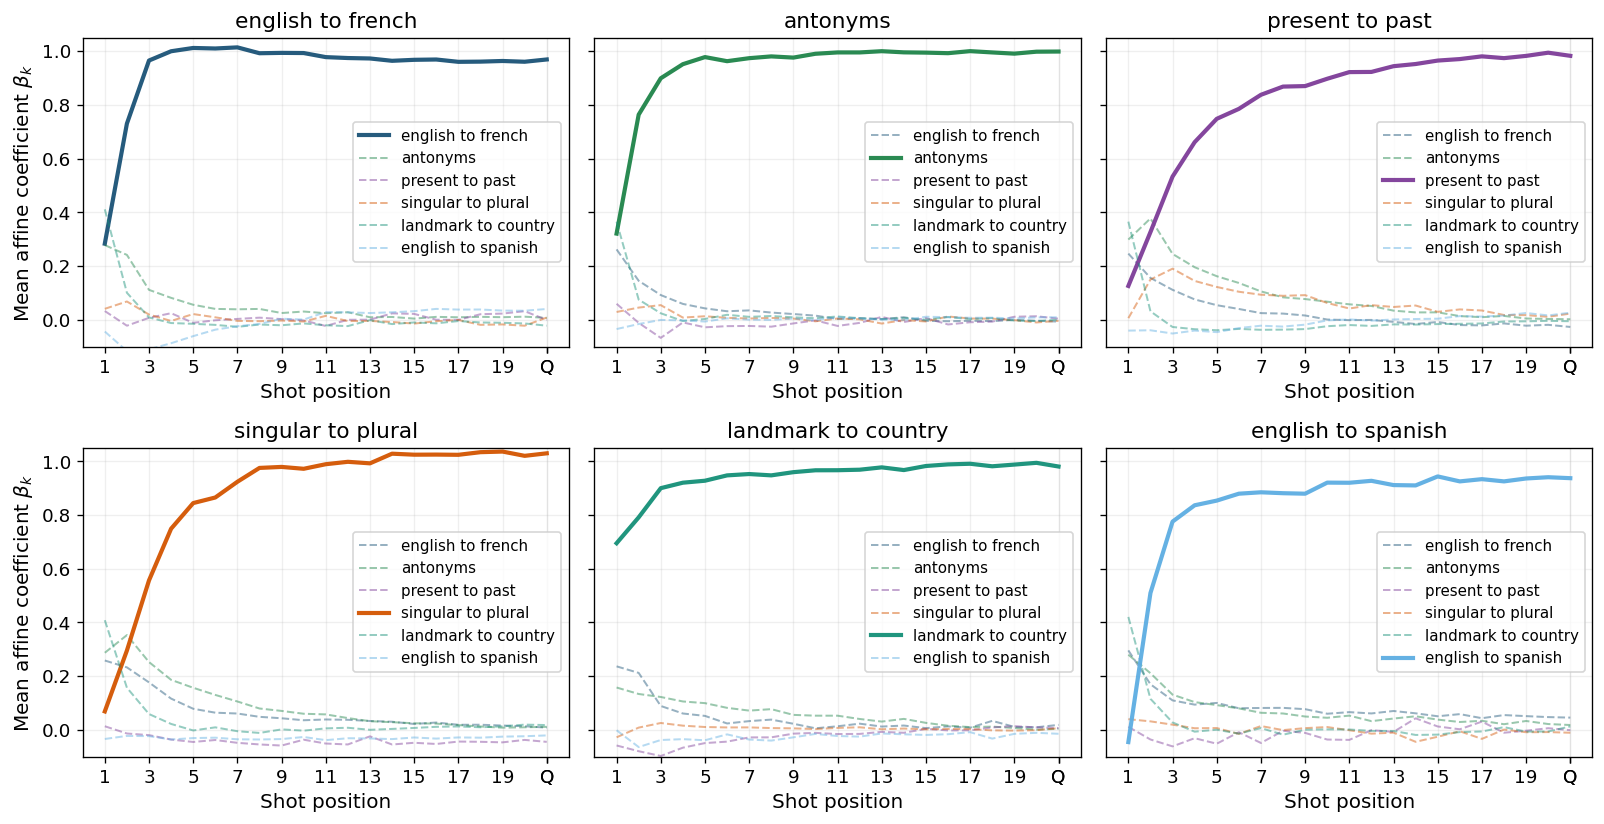

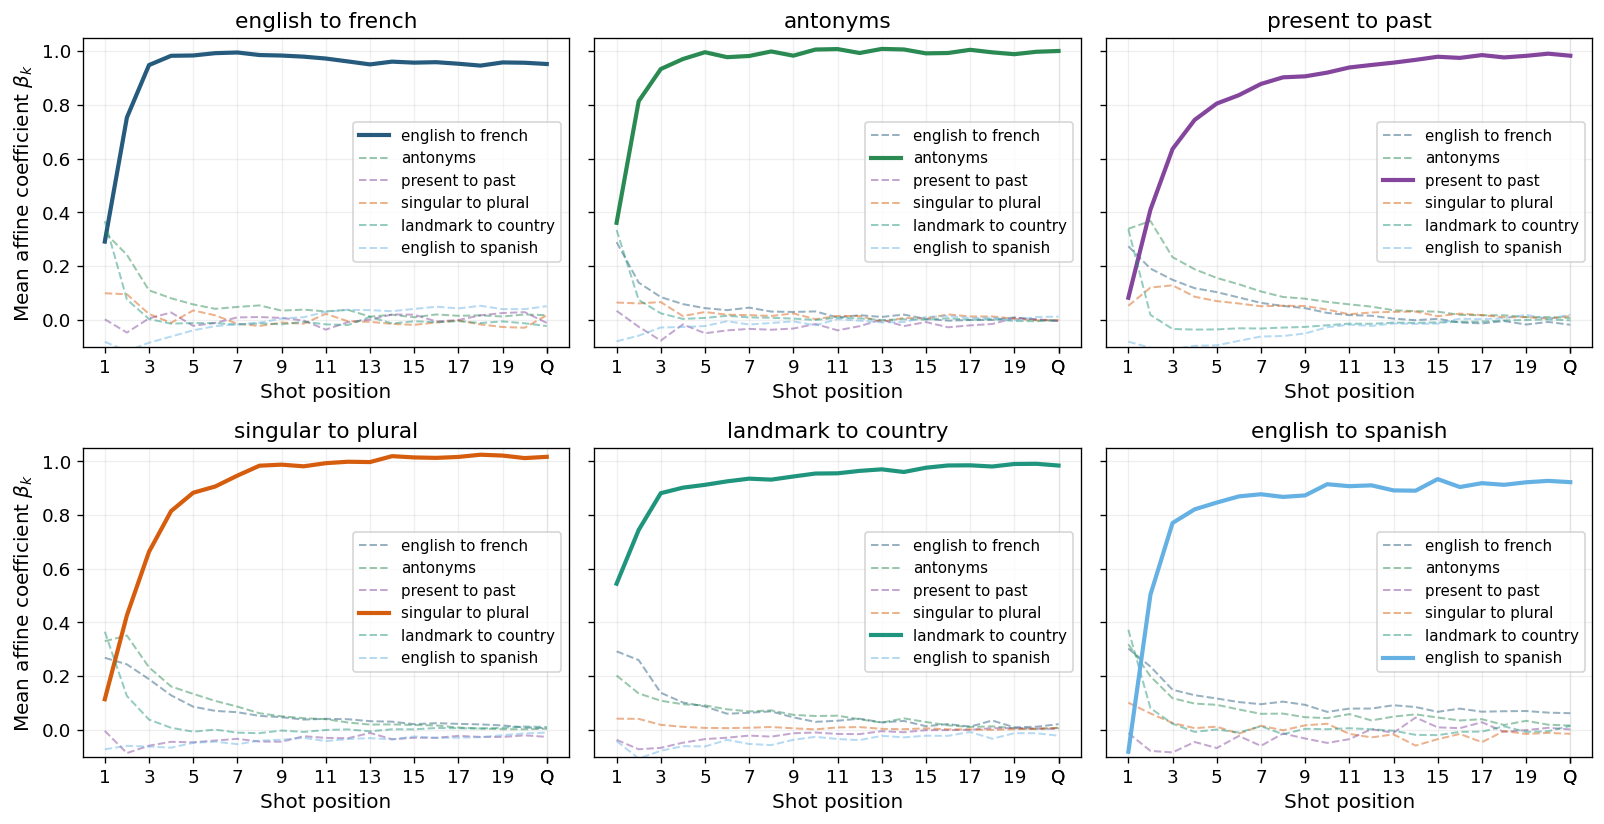

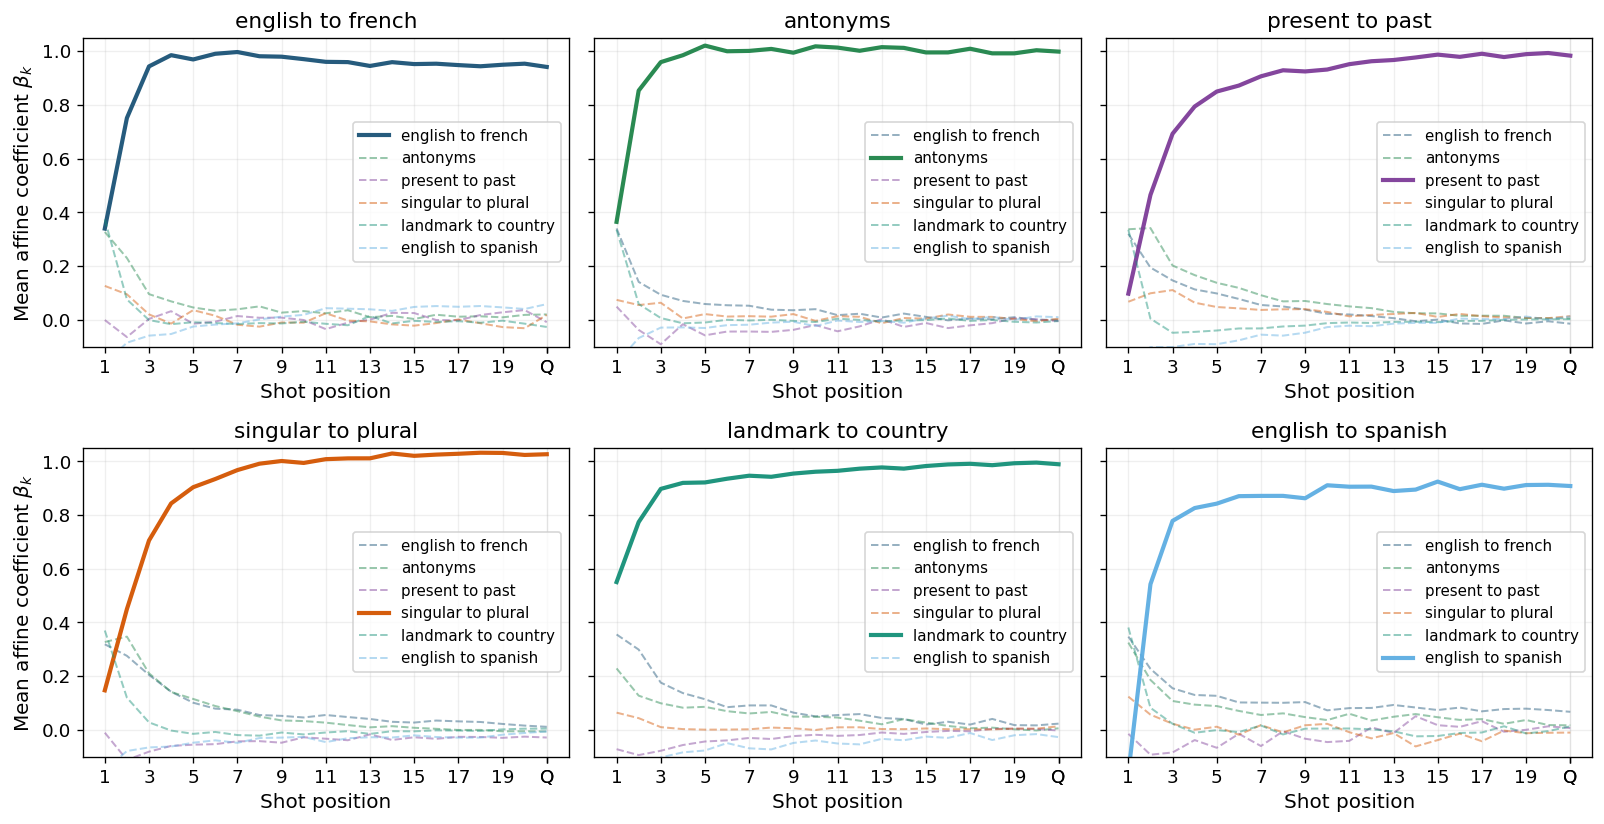

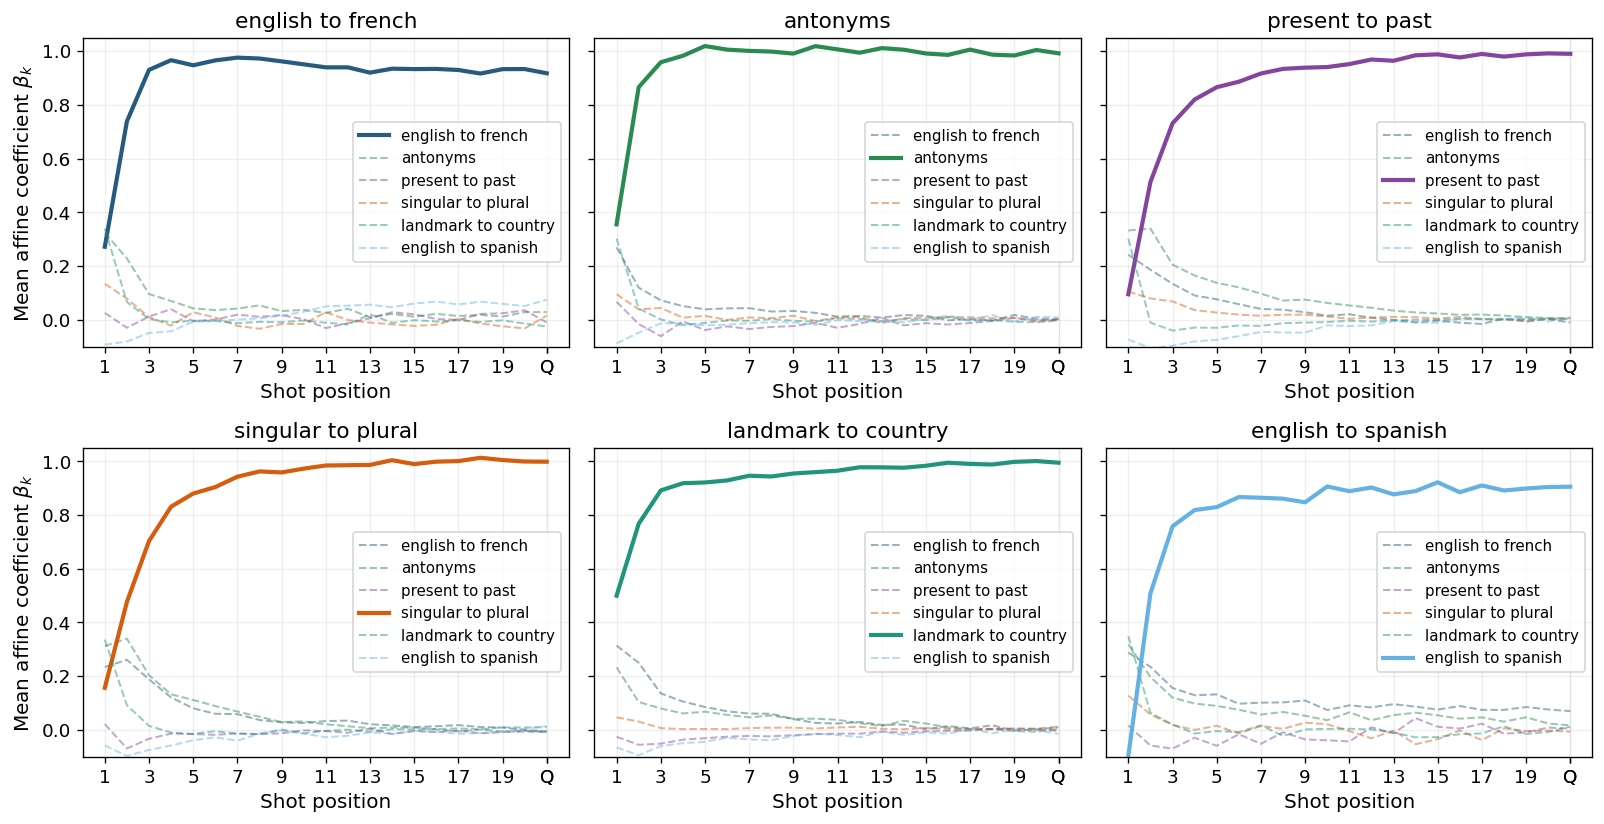

In [21]:
from icl.real_llm.plots import plot_lambda_id

plot_lambda_id(beta_pos_id, LAMBDA_TASK_NAMES, LAMBDA_LAYERS,
               T_traj=T_traj, N_SHOTS=N_SHOTS, K=K_lambda, save_dir='../paper_figs')

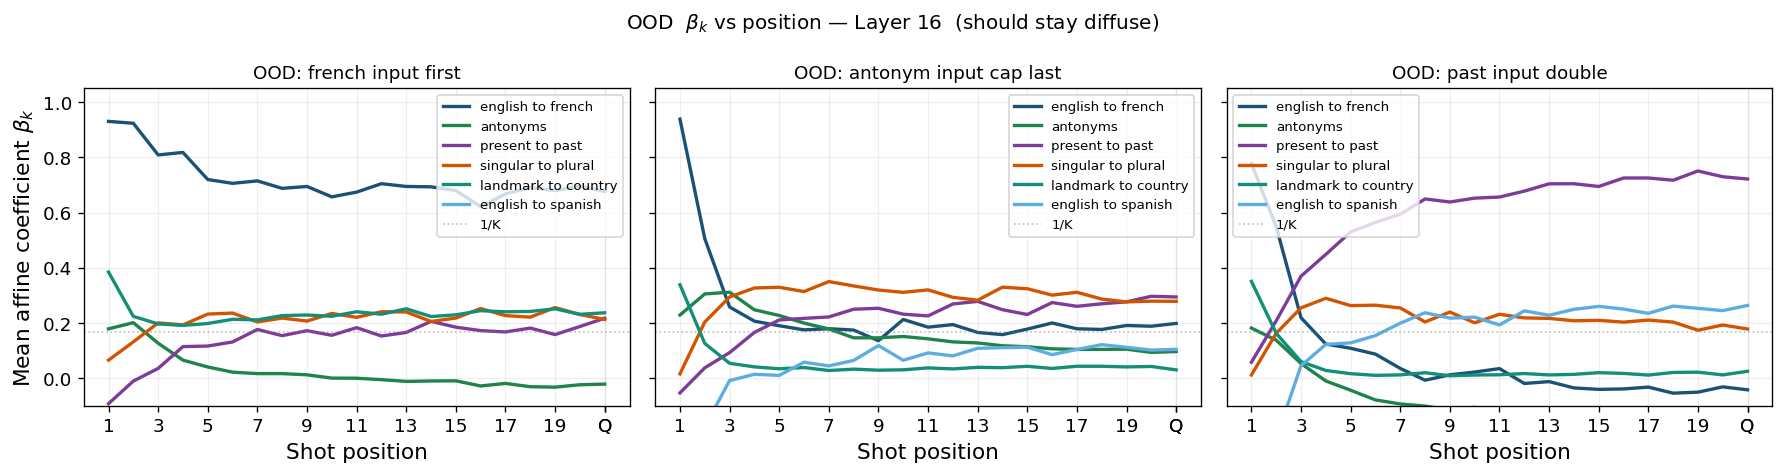

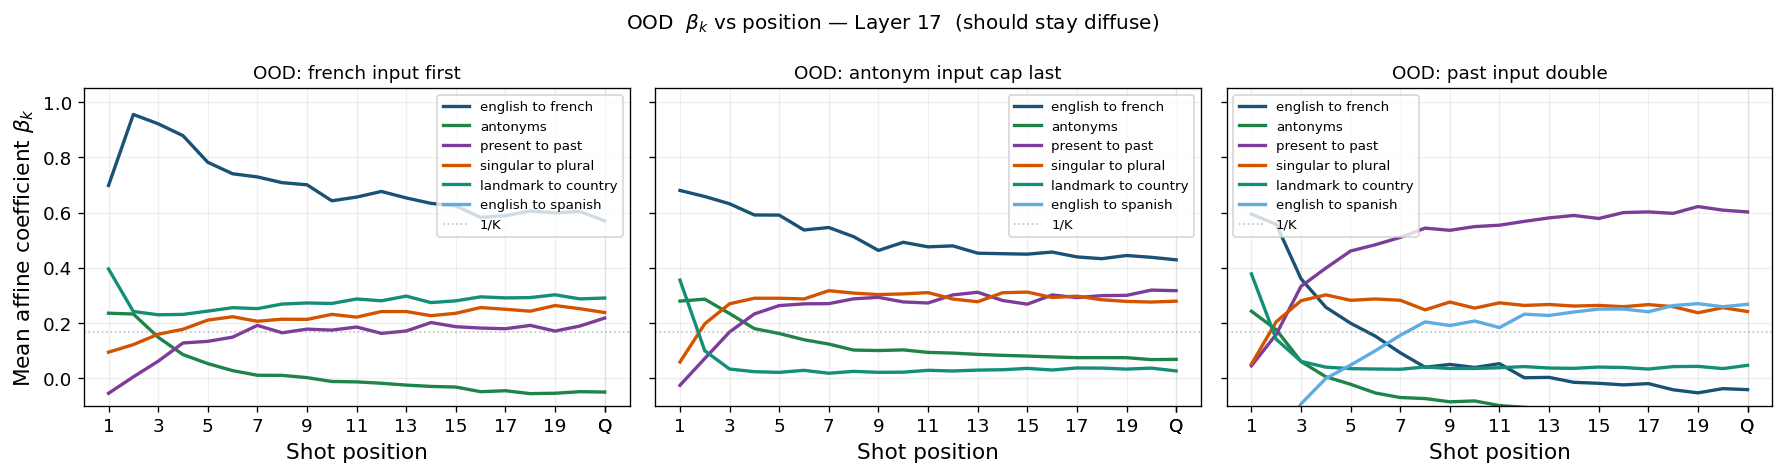

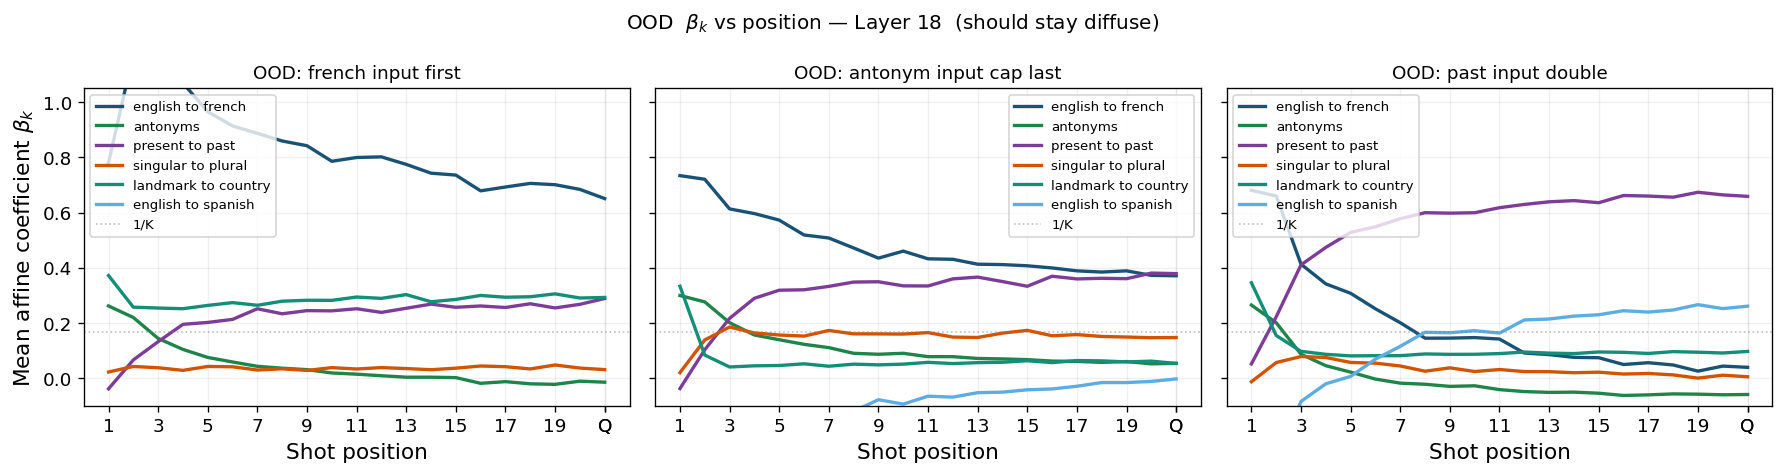

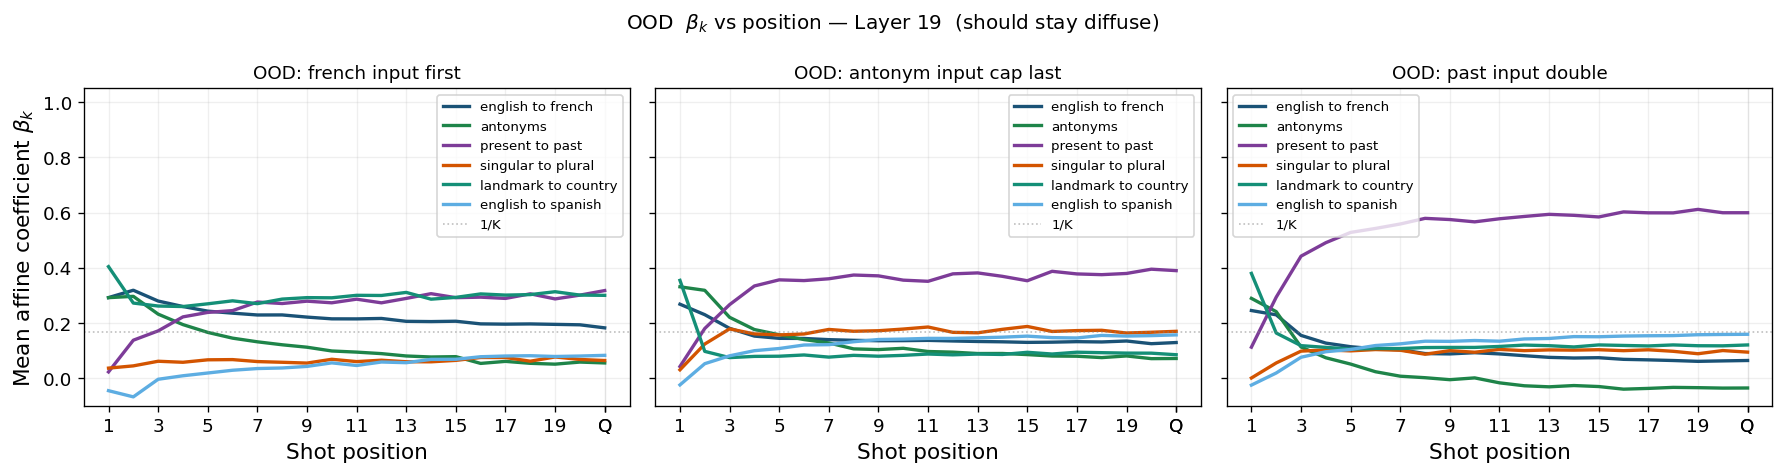

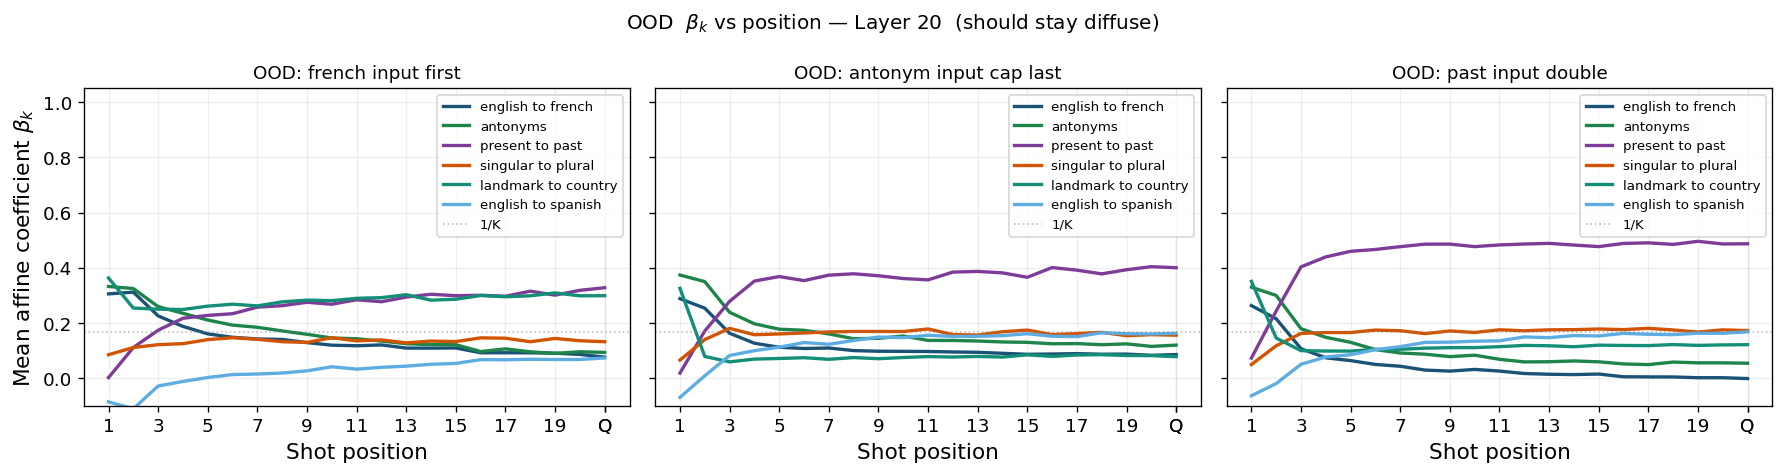

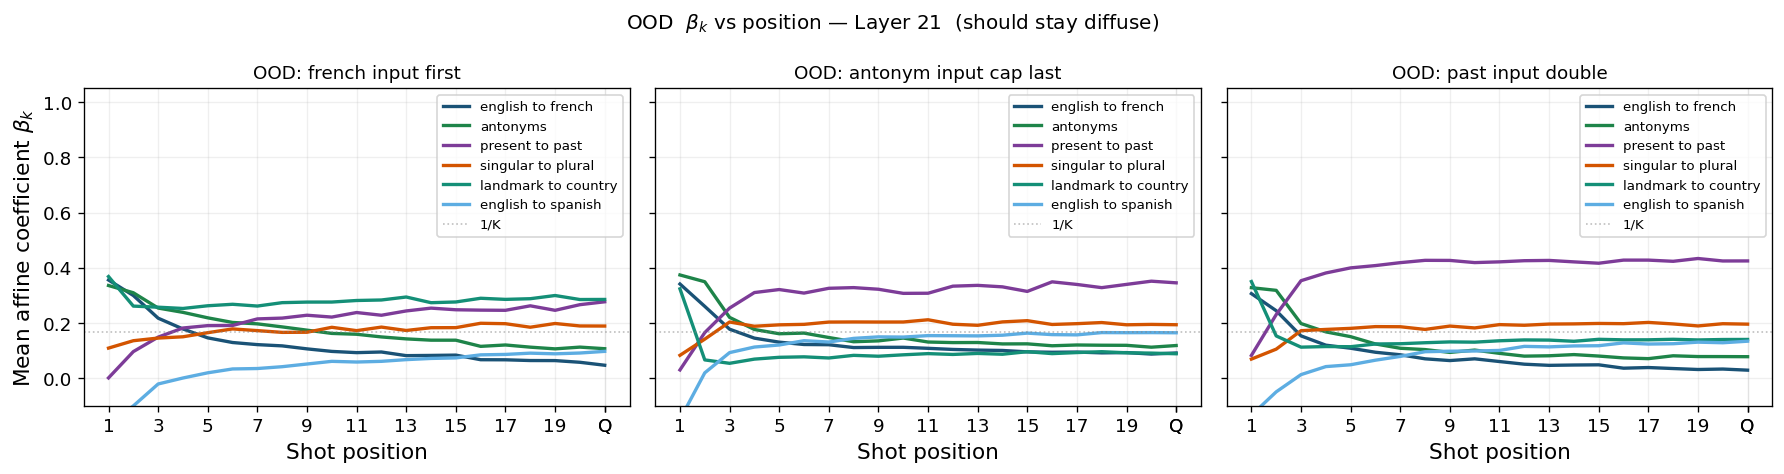

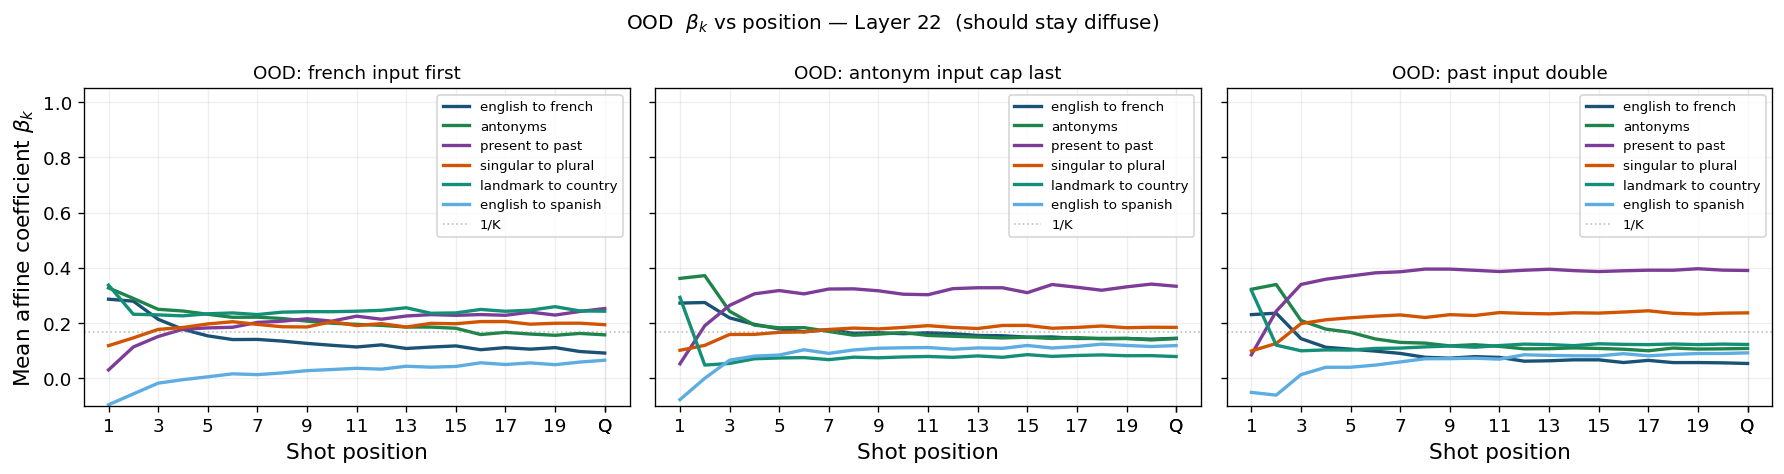

In [22]:
from icl.real_llm.plots import plot_lambda_ood

plot_lambda_ood(beta_pos_ood, LAMBDA_TASK_NAMES, LAMBDA_LAYERS,
                T_traj=T_traj, N_SHOTS=N_SHOTS, K=K_lambda, save_dir='../paper_figs')

## 11. Summary Table

In [23]:
# Mid-layer and last-layer R² summary
mid_layer  = L // 2
last_layer = L - 1

mid_hdr  = f'R² (mid={mid_layer})'
last_hdr = f'R² (last={last_layer})'
print(f'{"Group":<30} {mid_hdr:>20} {last_hdr:>22}')
print('-' * 74)

for name, r2 in id_r2.items():
    print(f'ID  {name:<26} {r2[mid_layer]:>20.3f} {r2[last_layer]:>22.3f}')
print()
for name, r2 in ood_r2.items():
    print(f'OOD {name:<26} {r2[mid_layer]:>20.3f} {r2[last_layer]:>22.3f}')

Group                                   R² (mid=14)           R² (last=27)
--------------------------------------------------------------------------
ID  english_to_french                         0.299                  0.386
ID  antonyms                                  0.412                  0.387
ID  present_to_past                           0.337                  0.430

OOD french_input_first                        0.045                  0.077
OOD antonym_input_cap_last                    0.045                  0.034
OOD past_input_double                         0.189                  0.083
